## Part 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/Shared drives/Spring Analytics Showdown/Challenge + Dataset/')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import statsmodels.api as sm
from xgboost import XGBClassifier

## Part 2. Data Loading and Exploration

- Read in all of the given csv's
- Cleaned column names
- Cleaned integer values - turned floats and strings to integers
- Changed farmer_fea_id to farmer_id in the farmer_details.
- Took a look at the data and some values.

In [ ]:
farmer = pd.read_csv('farmer_details.csv')
buyback = pd.read_csv('buyback_details.csv')
planting = pd.read_csv('planting_survey.csv')
loan = pd.read_csv('loan_details.csv')

In [ ]:
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        cleaned_col = col.strip().replace(' ', '_')
        new_cols.append(cleaned_col)
    df.columns = new_cols
    return df

farmer = clean_col_names(farmer)
buyback = clean_col_names(buyback)
planting = clean_col_names(planting)
loan = clean_col_names(loan)

print("Column names cleaned for all dataframes.")
print("Farmer columns:", farmer.columns.tolist())
print("Buyback columns:", buyback.columns.tolist())
print("Planting columns:", planting.columns.tolist())
print("Loan columns:", loan.columns.tolist())

Column names cleaned for all dataframes.
Farmer columns: ['farmer_fea_id', 'gender', 'farmer_created_at', 'dob', 'default_payment_method', 'association', 'camp_name', 'district_name', 'region_name', 'number_seasons', 'agroecological_zone']
Buyback columns: ['id', 'farmer_id', 'crop_class', 'crop_variety', 'bbk_payment_method', 'base_price', 'grade_a_price', 'grade_b_price', 'grade_c_price', 'total_weight', 'grade_a_weight', 'grade_b_weight', 'grade_c_weight', 'total_net_weight', 'net_owed_to_farmer', 'grade_a_cash_value', 'grade_b_cash_value', 'grade_c_cash_value', 'bbk_created_at']
Planting columns: ['id', 'farmer_id', 'crop_planted', 'Qty_kgs_planted', 'planting_date', 'spacing_cm_btwn_rows', 'more_than_one_seed_in_hole', 'rcvd_crop_training']
Loan columns: ['id', 'farmer_id', 'crop_variety_name', 'crop_class_name', 'initial_down_payment_value', 'package_name', 'package_cash_repayment', 'package_in_kind_repayment', 'package_hectares', 'account_package_created_at', 'program_name', 'fe

In [ ]:
print(f"Farmer dataset: {farmer.shape[0]} rows, {farmer.shape[1]} columns")
print(f"Buyback dataset: {buyback.shape[0]} rows, {buyback.shape[1]} columns")
print(f"Loan dataset: {loan.shape[0]} rows, {loan.shape[1]} columns")
print(f"Planting dataset: {planting.shape[0]} rows, {planting.shape[1]} columns")

Farmer dataset: 22597 rows, 11 columns
Buyback dataset: 24439 rows, 19 columns
Loan dataset: 39167 rows, 18 columns
Planting dataset: 19198 rows, 8 columns


In [ ]:
columns_to_convert = [
    'base_price',
    'grade_a_price',
    'grade_b_price',
    'grade_c_price',
    'total_weight',
    'grade_a_weight',
    'grade_b_weight',
    'grade_c_weight',
    'total_net_weight',
    'net_owed_to_farmer',
    'grade_a_cash_value',
    'grade_b_cash_value',
    'grade_c_cash_value'
]
for col in columns_to_convert:
    # Convert to string to handle mixed types, then clean
    buyback[col] = buyback[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
    # Convert to numeric, coercing errors to NaN
    buyback[col] = pd.to_numeric(buyback[col], errors='coerce')
    # Fill NaN values with 0 and then cast to integer
    buyback[col] = buyback[col].fillna(0).astype(int)

print("Data types after conversion:")
print(buyback[columns_to_convert].dtypes)
print("\nSample of cleaned buyback DataFrame:")
print(buyback[columns_to_convert].head())

Data types after conversion:
base_price            int64
grade_a_price         int64
grade_b_price         int64
grade_c_price         int64
total_weight          int64
grade_a_weight        int64
grade_b_weight        int64
grade_c_weight        int64
total_net_weight      int64
net_owed_to_farmer    int64
grade_a_cash_value    int64
grade_b_cash_value    int64
grade_c_cash_value    int64
dtype: object

Sample of cleaned buyback DataFrame:
   base_price  grade_a_price  grade_b_price  grade_c_price  total_weight  \
0          13             17             15             14           300   
1          13             17             15             14           871   
2          12             15             14             12           331   
3          13             17             15             14           631   
4          10             13             12             10           190   

   grade_a_weight  grade_b_weight  grade_c_weight  total_net_weight  \
0             300          

In [ ]:
farmer.head()

,farmer_fea_id,gender,farmer_created_at,dob,default_payment_method,association,camp_name,district_name,region_name,number_seasons,agroecological_zone
0,2504,female,22/09/2023,18/10/1992,paycode,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa
1,2511,male,23/09/2023,10/06/1982,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa
2,2512,male,23/09/2023,13/08/1996,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa
3,2513,male,23/09/2023,02/04/2000,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa
4,2516,female,23/09/2023,08/01/1992,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa


In [ ]:
buyback['farmer_id'].value_counts()

,count
farmer_id,
18178,27
19409,19
19404,17
40949,16
19418,16
...,...
15165,1
15177,1
15227,1


In [ ]:
loan[loan['farmer_id'] == 18178]

,id,farmer_id,crop_variety_name,crop_class_name,initial_down_payment_value,package_name,package_cash_repayment,package_in_kind_repayment,package_hectares,account_package_created_at,program_name,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard
3366,24195,18178,Kafue,Soy Bean,100.0,SOURCE Soybeans Kafue - Yellow (25 Kg),0,100,0.5,07/12/2024,SOURCE 2024/25,No,Yes,No,Yes,No,No,No
10572,24923,18178,Kafue,Soy Bean,100.0,SOURCE Soybeans Kafue - Yellow (25 Kg),0,100,0.5,07/12/2024,SOURCE 2024/25,No,Yes,No,Yes,No,No,No


if the farmer has only one loan, sum up all the buyback weight columns (also assuming date is in chronological order.

If possible, add planting assuming that planting date comes before buyback

In [ ]:
farmer = farmer.rename(columns={'farmer_fea_id': 'farmer_id'})
print(farmer.columns)

Index(['farmer_id', 'gender', 'farmer_created_at', 'dob',
       'default_payment_method', 'association', 'camp_name', 'district_name',
       'region_name', 'number_seasons', 'agroecological_zone'],
      dtype='object')


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
buyback[buyback['farmer_id'] == 2517]

,id,farmer_id,crop_class,crop_variety,bbk_payment_method,base_price,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,net_owed_to_farmer,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,bbk_created_at
1078,19208,2517,Soy Bean,Emerald,Paycode,12,15,14,12,1774,1774,0,0,1674,28320,25110,0,0,01/07/2025
1079,22393,2517,Soy Bean,Kafue,Paycode,12,15,14,12,237,150,0,87,237,3294,2250,0,1044,11/07/2025
2742,22324,2517,Soy Bean,Kafue,Paycode,12,15,14,12,1232,1232,0,0,1232,18480,18480,0,0,11/07/2025
2743,19207,2517,Soy Bean,Kafue,Paycode,12,15,14,12,750,750,0,0,450,4650,6750,0,0,01/07/2025


## Part 3. Dataset creation for final_df and others

### 3.1 Aggregating farmer and loans

- created subsets of the farmers who have id's in loan and buyback
- merged farmer and loan dataset on farmer_id - each row represents the farmer details and loan details for one package.
- aggregated the data on the farmer details and crop variety and summed up the package integers.
  - each row represents the farmer details and the total amount they owe as well as what they received in the packages for each crop class.
  - fertilizer and other package inputs were turned to binary, then multiplied by package_hectares before being summed to represent the total amount of input that farmer received for each crop class.
- took a look at some rows and values as well as data shape.

In [ ]:
farmer_set = farmer[farmer['farmer_id'].isin(loan['farmer_id'])]

In [ ]:
farmer_set1 = farmer_set[farmer_set['farmer_id'].isin(buyback['farmer_id'])] #only keeping track of farmers who have information in the buyback column

In [ ]:
len(farmer_set1)

17342

In [ ]:
farmer_loan = farmer_set1.merge(loan, on='farmer_id', how='inner')
farmer_loan.head()

,farmer_id,gender,farmer_created_at,dob,default_payment_method,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,id,crop_variety_name,crop_class_name,initial_down_payment_value,package_name,package_cash_repayment,package_in_kind_repayment,package_hectares,account_package_created_at,program_name,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard
0,2504,female,22/09/2023,18/10/1992,paycode,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,27253,Emerald,Soy Bean,100.0,SEED Soybeans TGX - Yellow (25 Kg),0,100,0.5,07/12/2024,SEED - 2024/ 25,No,Yes,No,Yes,No,No,No
1,2504,female,22/09/2023,18/10/1992,paycode,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,27240,Emerald,Soy Bean,100.0,SEED Soybeans TGX - Yellow (25 Kg),0,100,0.5,07/12/2024,SEED - 2024/ 25,No,Yes,No,Yes,No,No,No
2,2511,male,23/09/2023,10/06/1982,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,66182,Kafue,Soy Bean,100.0,SEED Soybeans Kafue - Yellow (25 Kg),0,100,0.5,21/01/2025,SEED - 2024/ 25,No,Yes,No,Yes,No,No,No
3,2512,male,23/09/2023,13/08/1996,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,26230,Kafue,Soy Bean,100.0,SEED Soybeans Kafue - Yellow (25 Kg),0,100,0.5,07/12/2024,SEED - 2024/ 25,No,Yes,No,Yes,No,No,No
4,2513,male,23/09/2023,02/04/2000,paycode,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,49215,Kafue,Soy Bean,100.0,SEED Soybeans Kafue - Yellow (25 Kg),0,100,0.5,07/12/2024,SEED - 2024/ 25,No,Yes,No,Yes,No,No,No


In [ ]:
farmer_loan_subset = farmer_loan[[
    'farmer_id',
    'gender',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'number_seasons',
    'agroecological_zone',
  #  'crop_variety_name',
    'crop_class_name',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'package_hectares',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]]

binary_cols = ['fertilizer', 'fungicide', 'gypsum', 'inoculant', 'insecticide', 'lime', 'seed_guard']

for col in binary_cols:
    farmer_loan_subset.loc[:, col] = farmer_loan_subset[col].map({'Yes': 1, 'No': 0})

for col in binary_cols:
    farmer_loan_subset.loc[:, col] = farmer_loan_subset[col] * farmer_loan_subset['package_hectares']

print("Binary columns multiplied by package_hectares:")
print(farmer_loan_subset[binary_cols + ['package_hectares']].head())

print("Converted 'Yes'/'No' columns to 1/0 in farmer_loan_subset:")
print(farmer_loan_subset[binary_cols].head())

Binary columns multiplied by package_hectares:
  fertilizer fungicide gypsum inoculant insecticide lime seed_guard  \
0        0.0       0.5    0.0       0.5         0.0  0.0        0.0   
1        0.0       0.5    0.0       0.5         0.0  0.0        0.0   
2        0.0       0.5    0.0       0.5         0.0  0.0        0.0   
3        0.0       0.5    0.0       0.5         0.0  0.0        0.0   
4        0.0       0.5    0.0       0.5         0.0  0.0        0.0   

   package_hectares  
0               0.5  
1               0.5  
2               0.5  
3               0.5  
4               0.5  
Converted 'Yes'/'No' columns to 1/0 in farmer_loan_subset:
  fertilizer fungicide gypsum inoculant insecticide lime seed_guard
0        0.0       0.5    0.0       0.5         0.0  0.0        0.0
1        0.0       0.5    0.0       0.5         0.0  0.0        0.0
2        0.0       0.5    0.0       0.5         0.0  0.0        0.0
3        0.0       0.5    0.0       0.5         0.0  0.0       

In [ ]:
farmer_loan_subset.head()

,farmer_id,gender,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,crop_class_name,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard
0,2504,female,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,Soy Bean,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0
1,2504,female,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,Soy Bean,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0
2,2511,male,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,Soy Bean,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0
3,2512,male,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,Soy Bean,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0
4,2513,male,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,Soy Bean,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0


In [ ]:
aggregated_loan_data = farmer_loan_subset.groupby([
    'farmer_id',
    'gender',
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'number_seasons',
    'agroecological_zone',
  #  'crop_variety_name',
]).agg({
    'initial_down_payment_value': 'sum',
    'package_cash_repayment': 'sum',
    'package_in_kind_repayment': 'sum',
    'package_hectares': 'sum',
    'fertilizer': 'sum',
    'fungicide': 'sum',
    'gypsum': 'sum',
    'inoculant': 'sum',
    'insecticide': 'sum',
    'lime': 'sum',
    'seed_guard': 'sum'
}).reset_index()

print(aggregated_loan_data.head())
print(aggregated_loan_data.shape)
print(aggregated_loan_data.columns.tolist())

   farmer_id  gender crop_class_name association camp_name district_name  \
0       2504  female        Soy Bean  GNA Farmer  Ng'ongwe    Kasenengwa   
1       2511    male        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   
2       2512    male        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   
3       2513    male        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   
4       2516  female        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   

  region_name  number_seasons agroecological_zone  initial_down_payment_value  \
0  Kasenengwa               3                 IIa                       200.0   
1  Kasenengwa               3                 IIa                       100.0   
2  Kasenengwa               2                 IIa                       100.0   
3  Kasenengwa               1                 IIa                       100.0   
4  Kasenengwa               5                 IIa                       200.0   

   package_cash_repayment  package_in_kind_repayment  pa

In [ ]:
aggregated_loan_data['farmer_id'].value_counts()

,count
farmer_id,
4918,4
7989,4
11077,3
17388,3
7869,3
...,...
19189,1
19192,1
19193,1


In [ ]:
aggregated_loan_data[aggregated_loan_data['farmer_id'] == 4918]

,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard
1448,4918,male,Cowpea,GNA Farmer,Katondo,Kasenengwa,Kasenengwa,2,IIa,0.0,0,65,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.5
1449,4918,male,Maize,GNA Farmer,Katondo,Kasenengwa,Kasenengwa,2,IIa,0.0,5800,0,0.5,0.5,0.0,0.0,0.0,0.5,0.0,0.0
1450,4918,male,Product,GNA Farmer,Katondo,Kasenengwa,Kasenengwa,2,IIa,0.0,270,0,0.0,0,0,0,0,0,0,0
1451,4918,male,Soy Bean,GNA Farmer,Katondo,Kasenengwa,Kasenengwa,2,IIa,300.0,0,450,2.0,0.5,1.5,0.0,1.5,0.0,0.5,0.0


In [ ]:
buyback[buyback['farmer_id'] == 4918].sort_values(by='crop_variety')

,id,farmer_id,crop_class,crop_variety,bbk_payment_method,base_price,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,net_owed_to_farmer,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,bbk_created_at
959,14475,4918,Soy Bean,Emerald,Paycode,12,15,14,12,412,412,0,0,412,5530,6180,0,0,18/06/2025
960,11205,4918,Soy Bean,Emerald,Paycode,13,17,15,14,46,46,0,0,46,782,782,0,0,09/06/2025
2635,9022,4918,Soy Bean,Emerald,Paycode,13,17,15,14,460,460,0,0,360,3678,6120,0,0,02/06/2025
961,10139,4918,Soy Bean,Kafue,Paycode,13,17,15,14,100,100,0,0,100,1400,1700,0,0,05/06/2025
962,9127,4918,Soy Bean,Kafue,Paycode,13,17,15,14,137,137,0,0,137,2329,2329,0,0,03/06/2025
2637,9023,4918,Soy Bean,Kafue,Paycode,13,17,15,14,908,908,0,0,558,11414,9486,0,0,02/06/2025
2636,1418,4918,Cowpea,Lutembwe,Paycode,10,13,12,10,338,0,338,0,273,-3774,0,3276,0,05/05/2025
2638,9021,4918,Cowpea,Lutembwe,Paycode,10,13,12,10,111,0,111,0,111,-2442,0,1332,0,02/06/2025


In [ ]:
aggregated_loan_data[aggregated_loan_data['farmer_id'] == 42443]

,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard
19131,42443,female,Sugar bean,GNA Farmer,Dormant Farmers - Northern,Chipili,Northern,1,III,0.0,0,105,0.25,0.0,0.0,0.0,0.25,0.25,0.0,0.0


In [ ]:
buyback[buyback['farmer_id'] == 42443].sort_values(by='crop_variety')

,id,farmer_id,crop_class,crop_variety,bbk_payment_method,base_price,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,net_owed_to_farmer,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,bbk_created_at
22652,20482,42443,Sugar bean,Lungwebungu,Airtel Money,22,25,22,22,66,66,0,0,0,0,0,0,0,04/07/2025


In [ ]:
buyback['crop_class'].value_counts()

,count
crop_class,
Soy Bean,14579
Sugar bean,3391
Groundnut,3155
Navy Bean,2908
Cowpea,277
Sunflower,129


In [ ]:
planting['crop_planted'].value_counts()

,count
crop_planted,
Soybean,10392
Beans,5344
Groundnuts,3394
Maize,56
Sunflower,12


In [ ]:
len(aggregated_loan_data)

19159

In [ ]:
aggregated_loan_data['farmer_id'].nunique()

17342

### 3.2 Aggregating farmer and buyback - This results in the final and most used dataset

- merged buyback information with the aggregated farmer and loans information.
  - each row now includes the total weight of crops that a farmer brought in for each crop class as well as the total net weight and the weight for each grade of crop brought.

In [ ]:
buyback_subset = buyback[[
    'farmer_id',
    'crop_class',
    'total_weight',
    'grade_a_price',
    'grade_b_price',
    'grade_c_price',
    'grade_a_weight',
    'grade_b_weight',
    'grade_c_weight',
    'total_net_weight',
    'grade_a_cash_value',
    'grade_b_cash_value',
    'grade_c_cash_value'
]]

In [ ]:
aggregated_buyback_data = buyback_subset.groupby([
    'farmer_id',
    'crop_class',
    'grade_a_price',
    'grade_b_price',
    'grade_c_price'
]).agg({
    'total_weight': 'sum',
    'grade_a_weight': 'sum',
    'grade_b_weight': 'sum',
    'grade_c_weight': 'sum',
    'total_net_weight': 'sum',
    'grade_a_cash_value': 'sum',
    'grade_b_cash_value': 'sum',
    'grade_c_cash_value': 'sum'
}).reset_index()

print("Aggregated buyback data head:")
print(aggregated_buyback_data.head())
print("\nAggregated buyback data shape:")
print(aggregated_buyback_data.shape)
print("\nAggregated buyback data columns:")
print(aggregated_buyback_data.columns.tolist())

Aggregated buyback data head:
   farmer_id crop_class  grade_a_price  grade_b_price  grade_c_price  \
0       2504   Soy Bean             15             14             12   
1       2511   Soy Bean             15             14             12   
2       2512   Soy Bean             15             14             12   
3       2513   Soy Bean             15             14             12   
4       2516   Soy Bean             15             14             12   

   total_weight  grade_a_weight  grade_b_weight  grade_c_weight  \
0           550             550               0               0   
1          1139            1139               0               0   
2           805             805               0               0   
3           344             344               0               0   
4          1536            1536               0               0   

   total_net_weight  grade_a_cash_value  grade_b_cash_value  \
0               350                5250                   0   
1       

In [ ]:
# Rename 'crop_class' in aggregated_buyback_data to 'crop_class_name' for consistent merging
aggregated_buyback_data_renamed = aggregated_buyback_data.rename(columns={'crop_class': 'crop_class_name'})

# Merge aggregated_loan_data and aggregated_buyback_data on 'farmer_id' and 'crop_class_name'
final_df = pd.merge(aggregated_loan_data, aggregated_buyback_data_renamed, on=['farmer_id', 'crop_class_name'], how='inner')

print("Final DataFrame head:")
print(final_df.head())
print("\nFinal DataFrame shape:")
print(final_df.shape)
print("\nFinal DataFrame columns:")
print(final_df.columns.tolist())

Final DataFrame head:
   farmer_id  gender crop_class_name association camp_name district_name  \
0       2504  female        Soy Bean  GNA Farmer  Ng'ongwe    Kasenengwa   
1       2511    male        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   
2       2512    male        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   
3       2513    male        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   
4       2516  female        Soy Bean  GNA Farmer   Mzapawi    Kasenengwa   

  region_name  number_seasons agroecological_zone  initial_down_payment_value  \
0  Kasenengwa               3                 IIa                       200.0   
1  Kasenengwa               3                 IIa                       100.0   
2  Kasenengwa               2                 IIa                       100.0   
3  Kasenengwa               1                 IIa                       100.0   
4  Kasenengwa               5                 IIa                       200.0   

   package_cash_repayment  package

In [ ]:
final_df.head()

,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value
0,2504,female,Soy Bean,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,550,550,0,0,350,5250,0,0
1,2511,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,1139,1139,0,0,1039,15585,0,0
2,2512,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,805,805,0,0,705,10575,0,0
3,2513,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,344,344,0,0,244,3660,0,0
4,2516,female,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,1536,1536,0,0,1336,20040,0,0


In [ ]:
final_df['finished_paying'] = (final_df['total_weight'] >= final_df['package_in_kind_repayment']).astype(int)

print("Final DataFrame with 'finished_paying' column:")
display(final_df.head())

print("\nValue counts for 'finished_paying' column:")
display(final_df['finished_paying'].value_counts())

Final DataFrame with 'finished_paying' column:


,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,finished_paying
0,2504,female,Soy Bean,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,550,550,0,0,350,5250,0,0,1
1,2511,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,1139,1139,0,0,1039,15585,0,0,1
2,2512,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,805,805,0,0,705,10575,0,0,1
3,2513,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,344,344,0,0,244,3660,0,0,1
4,2516,female,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,1536,1536,0,0,1336,20040,0,0,1



Value counts for 'finished_paying' column:


,count
finished_paying,
1,15470
0,3477


In [ ]:
#final_df.to_csv('final_df.csv', index=False)

### 3.3 Planting Survey
- in order to look at the per crop class information for some of the models and to also take into account planting_survey details, more datasets were created.
- These combine sugar bean and navy beans to bean and then matches the info from the final_df to get the following datasets.

Shape of soy_bean_final_df: (8913, 39)

Shape of groundnut_final_df: (1868, 39)

Shape of sunflower_final_df: (9, 39)

Shape of beans_final_df: (4987, 40)

Although for further analysis, only soy_bean, ground_nut, and beans will be used since they have the most data.

In [ ]:
planting['crop_planted'].value_counts()

,count
crop_planted,
Soybean,10392
Beans,5344
Groundnuts,3394
Maize,56
Sunflower,12


In [ ]:
planting_for_merge = planting.copy()
# Convert farmer_id in planting to int for merging, handling potential NaNs
planting_for_merge['farmer_id'] = planting_for_merge['farmer_id'].fillna(0).astype(int)

# Standardize crop_planted names to match crop_class_name in final_df
crop_name_mapping = {
    'Soybean': 'Soy Bean',
    'Groundnuts': 'Groundnut',
    'Sugar bean': 'Beans',
    'Navy Bean': 'Beans'
    # 'Sunflower' is already consistent
    # 'Beans' and 'Maize' don't have a direct 1-to-1 match in final_df's crop_class_name list
    # and the user asked for crop_class_name and crop_planted to be the same.
    # Therefore, rows with 'Beans' or 'Maize' in crop_planted will not match
    # any specific crop_class_name in final_df during the inner join,
    # unless they are explicitly mapped to one of the available crop_class_name values.
    # For this task, we will rely on exact matches based on the prompt.
}
planting_for_merge['crop_planted'] = planting_for_merge['crop_planted'].replace(crop_name_mapping)

# --- Create datasets for each crop_class_name from final_df ---

# 2. Separate datasets for other crop classes
soy_bean_df = final_df[final_df['crop_class_name'] == 'Soy Bean'].copy()
beans_df = final_df[final_df['crop_class_name'].isin(['Sugar bean', 'Navy Bean'])].copy()
groundnut_df = final_df[final_df['crop_class_name'] == 'Groundnut'].copy()
cowpea_df = final_df[final_df['crop_class_name'] == 'Cowpea'].copy()
sunflower_df = final_df[final_df['crop_class_name'] == 'Sunflower'].copy()

# --- Perform inner joins with planting_for_merge ---

# Prepare beans_df for merging by creating a temporary column with 'Beans' as the crop class name
beans_df_for_merge = beans_df.copy()
beans_df_for_merge['temp_crop_class_name'] = beans_df_for_merge['crop_class_name'].replace({
    'Sugar bean': 'Beans',
    'Navy Bean': 'Beans'
})

# Join for Sugar bean and Navy Bean combined
beans_merged_df = pd.merge(
    beans_df_for_merge,
    planting_for_merge,
    left_on=['farmer_id', 'temp_crop_class_name'],
    right_on=['farmer_id', 'crop_planted'],
    how='inner'
)

# Join for Soy Bean
soy_bean_merged_df = pd.merge(
    soy_bean_df,
    planting_for_merge,
    left_on=['farmer_id', 'crop_class_name'],
    right_on=['farmer_id', 'crop_planted'],
    how='inner'
)

# Join for Groundnut
groundnut_merged_df = pd.merge(
    groundnut_df,
    planting_for_merge,
    left_on=['farmer_id', 'crop_class_name'],
    right_on=['farmer_id', 'crop_planted'],
    how='inner'
)

# Join for Sunflower
sunflower_merged_df = pd.merge(
    sunflower_df,
    planting_for_merge,
    left_on=['farmer_id', 'crop_class_name'],
    right_on=['farmer_id', 'crop_planted'],
    how='inner'
)

print("Shape of soy_bean_merged_df:", soy_bean_merged_df.shape)
print("Shape of groundnut_merged_df:", groundnut_merged_df.shape)
print("Shape of sunflower_merged_df:", sunflower_merged_df.shape)
print("Shape of beans_merged_df:", beans_merged_df.shape)

Shape of soy_bean_merged_df: (8913, 39)
Shape of groundnut_merged_df: (1868, 39)
Shape of sunflower_merged_df: (9, 39)
Shape of beans_merged_df: (4987, 40)


In [ ]:
final_df['crop_class_name'].value_counts()

,count
crop_class_name,
Soy Bean,10643
Sugar bean,2978
Groundnut,2473
Navy Bean,2471
Cowpea,254
Sunflower,128


In [ ]:
soybean_final_df = soy_bean_merged_df.copy()
groundnut_final_df = groundnut_merged_df.copy()
beans_final_df = beans_merged_df.drop(columns=['temp_crop_class_name']).copy()

print("Soybean Final DataFrame:")
display(soybean_final_df.head())
print(f"Shape: {soybean_final_df.shape}\n")

print("Groundnut Final DataFrame:")
display(groundnut_final_df.head())
print(f"Shape: {groundnut_final_df.shape}\n")

print("Beans Final DataFrame:")
display(beans_final_df.head())
print(f"Shape: {beans_final_df.shape}\n")

Soybean Final DataFrame:


,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,finished_paying,id,crop_planted,Qty_kgs_planted,planting_date,spacing_cm_btwn_rows,more_than_one_seed_in_hole,rcvd_crop_training
0,2504,female,Soy Bean,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,550,550,0,0,350,5250,0,0,1,91743,Soy Bean,50,25/12/2024,65,Yes,Yes
1,2511,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,1139,1139,0,0,1039,15585,0,0,1,81674,Soy Bean,25,25/12/2024,40,Yes,Yes
2,2512,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,805,805,0,0,705,10575,0,0,1,97846,Soy Bean,25,08/01/2025,50,Yes,Yes
3,2513,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,344,344,0,0,244,3660,0,0,1,98624,Soy Bean,25,08/01/2025,45,Yes,Yes
4,2516,female,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,1536,1536,0,0,1336,20040,0,0,1,96936,Soy Bean,50,16/12/2024,50,Yes,Yes


Shape: (8913, 39)

Groundnut Final DataFrame:


,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,finished_paying,id,crop_planted,Qty_kgs_planted,planting_date,spacing_cm_btwn_rows,more_than_one_seed_in_hole,rcvd_crop_training
0,3842,male,Groundnut,GNA Farmer,Nkhanga,Nkhanga,Chipangali,3,IIa,750.0,0,300,1.5,0.0,0.0,1.5,1.5,1.5,0.0,0.0,16,14,13,2151,2151,0,0,1851,29616,0,0,1,93418,Groundnut,20,01/01/2025,50,No,Yes
1,3990,male,Groundnut,GNA Farmer,Nkhanga,Nkhanga,Chipangali,3,IIa,500.0,0,200,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,16,14,13,254,38,216,0,54,608,232,0,1,82799,Groundnut,20,29/11/2024,50,No,Yes
2,3992,female,Groundnut,GNA Farmer,Nkhanga,Nkhanga,Chipangali,2,IIa,500.0,0,200,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,16,14,13,333,333,0,0,133,2128,0,0,1,80604,Groundnut,40,16/12/2024,50,No,Yes
3,3993,male,Groundnut,GNA Farmer,Nkhanga,Nkhanga,Chipangali,2,IIa,1000.0,0,400,2.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,16,14,13,900,900,0,0,500,8000,0,0,1,81185,Groundnut,80,14/12/2024,50,No,Yes
4,3995,female,Groundnut,GNA Farmer,Nkhanga,Nkhanga,Chipangali,2,IIa,500.0,0,200,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,16,14,13,422,422,0,0,222,3552,0,0,1,93994,Groundnut,40,01/01/2025,50,No,Yes


Shape: (1868, 39)

Beans Final DataFrame:


,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,finished_paying,id,crop_planted,Qty_kgs_planted,planting_date,spacing_cm_btwn_rows,more_than_one_seed_in_hole,rcvd_crop_training
0,2630,male,Navy Bean,GNA Farmer,Luwingu A,Luwingu,Northern,3,III,750.0,0,50,0.25,0.0,0.0,0.0,0.25,0.25,0.0,0.0,23,21,21,300,300,0,0,250,5750,0,0,1,109759,Beans,40,08/02/2025,75,No,Yes
1,2630,male,Sugar bean,GNA Farmer,Luwingu A,Luwingu,Northern,3,III,650.0,0,50,0.25,0.0,0.0,0.0,0.25,0.25,0.0,0.0,25,22,22,400,400,0,0,350,8750,0,0,1,109759,Beans,40,08/02/2025,75,No,Yes
2,2631,male,Navy Bean,GNA Farmer,Chipili,Chipili,Northern,3,III,1125.0,0,225,0.75,0.0,0.0,0.0,0.75,0.75,0.0,0.0,23,21,21,262,262,0,0,37,851,0,0,1,103690,Beans,60,04/02/2025,60,No,Yes
3,2632,male,Navy Bean,GNA Farmer,Chipili,Chipili,Northern,2,III,1500.0,0,200,0.75,0.0,0.0,0.0,0.75,0.75,0.0,0.0,23,21,21,200,200,0,0,0,0,0,0,1,101802,Beans,60,05/02/2025,60,No,Yes
4,2635,male,Navy Bean,GNA Farmer,Chipili,Chipili,Northern,2,III,750.0,0,150,0.50,0.0,0.0,0.0,0.5,0.5,0.0,0.0,23,21,21,263,263,0,0,113,2599,0,0,1,102095,Beans,40,03/02/2025,60,No,Yes


Shape: (4987, 39)



## Part 4. Predictive Objective and Input Effectiveness

Develop a model to predict expected farmer yield (or crop buyback potential) using the available data from the provided datasets. Evaluate model performance and identify the most significant predictors.

In this section, the inputs are being used as part of the prediction models so these two got combined.

### 4.1 Define our categorical and numerical datasets and process them

In [ ]:
final_df['total_weight'] # target variable

,total_weight
0,550
1,1139
2,805
3,344
4,1536
...,...
18942,472
18943,400
18944,700
18945,422


In [ ]:
final_df.columns # column names

Index(['farmer_id', 'gender', 'crop_class_name', 'association', 'camp_name',
       'district_name', 'region_name', 'number_seasons', 'agroecological_zone',
       'initial_down_payment_value', 'package_cash_repayment',
       'package_in_kind_repayment', 'package_hectares', 'fertilizer',
       'fungicide', 'gypsum', 'inoculant', 'insecticide', 'lime', 'seed_guard',
       'grade_a_price', 'grade_b_price', 'grade_c_price', 'total_weight',
       'grade_a_weight', 'grade_b_weight', 'grade_c_weight',
       'total_net_weight', 'grade_a_cash_value', 'grade_b_cash_value',
       'grade_c_cash_value', 'finished_paying'],
      dtype='object')

In [ ]:
# here is where we defined which variables we wanted to include as categorical and numerical as well as our target.
target_variable = final_df['total_weight']

categorical_variables = final_df[[
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender'
]]

numerical_variables = final_df[[
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]]

In [ ]:
#Data preprocessing
# Combine numerical and categorical features into a single DataFrame X
X = pd.concat([numerical_variables, categorical_variables], axis=1)
y = target_variable

# Define preprocessing steps
# One-hot encode categorical features
categorical_features = categorical_variables.columns.tolist()
# Standard scale numerical features
numerical_features = numerical_variables.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # Added sparse_output=False
    ])

### 4.2 Base linear model

- Tries to predict target weight based off of the numerical and categorical variables combined.

In [ ]:
# --- Linear Regression Model ---
print("\n--- Linear Regression Model ---")
# Data split for Linear Regression (80:20 train-test)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline for Linear Regression
linear_regression_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                               ('regressor', LinearRegression())])

# Train the Linear Regression model
linear_regression_pipeline.fit(X_train_lr, y_train_lr)

# Make predictions on the test set
y_pred_lr = linear_regression_pipeline.predict(X_test_lr)

# Evaluate Linear Regression model performance
mse_lr = mean_squared_error(y_test_lr, y_pred_lr)
r2_lr = r2_score(y_test_lr, y_pred_lr)

print(f"Linear Regression - Mean Squared Error: {mse_lr:.2f}")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")


--- Linear Regression Model ---
Linear Regression - Mean Squared Error: 269205.78
Linear Regression - R-squared: 0.30


In [ ]:
#This cell just returns the coefficients from the linear regression

# --- Linear Regression Model Details ---
print("\n--- Linear Regression Model Performance ---")
# Training R-squared
y_train_pred_lr = linear_regression_pipeline.predict(X_train_lr)
r2_train_lr = r2_score(y_train_lr, y_train_pred_lr)
print(f"Linear Regression - Training R-squared: {r2_train_lr:.2f}")
print(f"Linear Regression - Testing R-squared: {r2_lr:.2f}") # Already computed

# Extract coefficients and feature names
# Get feature names from preprocessor
ohe_feature_names_lr = linear_regression_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names_lr = numerical_features + list(ohe_feature_names_lr)
coefficients_lr = linear_regression_pipeline.named_steps['regressor'].coef_

print("\n--- Linear Regression Coefficients ---")
# Create a DataFrame for better readability
coefficients_df_lr = pd.DataFrame({'Feature': all_feature_names_lr, 'Coefficient': coefficients_lr})
print(coefficients_df_lr.sort_values(by='Coefficient', ascending=False).to_string())

print("\n--- Linear Regression P-values ---")
# To get p-values, we use statsmodels. This requires transforming the data and adding a constant.
# First, transform the training data using the preprocessor
X_train_transformed_lr = linear_regression_pipeline.named_steps['preprocessor'].transform(X_train_lr)

# Convert to DataFrame with feature names
X_train_transformed_df_lr = pd.DataFrame(X_train_transformed_lr, columns=all_feature_names_lr)

# Add a constant (intercept) term for statsmodels
X_train_transformed_df_lr = sm.add_constant(X_train_transformed_df_lr)

# Reset index of y_train_lr to align with X_train_transformed_df_lr if necessary
# This ensures both endog and exog have aligned indices, which is crucial for statsmodels
y_train_lr_reset = y_train_lr.reset_index(drop=True)

# Fit the OLS model
ols_model_lr = sm.OLS(y_train_lr_reset, X_train_transformed_df_lr)
ols_results_lr = ols_model_lr.fit()

# Print p-values
print(ols_results_lr.pvalues.sort_values(ascending=False).to_string())


--- Linear Regression Model Performance ---
Linear Regression - Training R-squared: 0.27
Linear Regression - Testing R-squared: 0.30

--- Linear Regression Coefficients ---
                                         Feature  Coefficient
77                      camp_name_Mulambwa South  1753.899600
145                          region_name_Western   776.418851
14                     crop_class_name_Navy Bean   771.749011
147                agroecological_zone_I and IIa   743.706824
126                       district_name_Mulambwa   715.369477
16                    crop_class_name_Sugar bean   644.466445
150              agroecological_zone_IIa and III   403.554106
56                            camp_name_Kwenje A   298.212474
91                            camp_name_Ngabwe 1   295.664682
80                        camp_name_Mumbwa North   278.798576
44                    camp_name_Kalumwange South   250.641383
92                            camp_name_Ngabwe 2   218.153309
110                 

In [ ]:
results_df = pd.DataFrame({
    'Coefficient': ols_results_lr.params,
    'P_Value': ols_results_lr.pvalues
})

# Drop the 'const' row if it exists, as it's an intercept and not a feature
if 'const' in results_df.index:
    results_df = results_df.drop('const')

# Add significance columns
results_df['Significant_0.01'] = results_df['P_Value'] < 0.01
results_df['Significant_0.05'] = results_df['P_Value'] < 0.05
results_df['Significant_0.1'] = results_df['P_Value'] < 0.1

print("\n--- Linear Regression Coefficients and P-values (Sorted by P-Value) ---")
display(results_df.sort_values(by='P_Value'))


--- Linear Regression Coefficients and P-values (Sorted by P-Value) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
number_seasons,8.832314e+01,3.869915e-44,True,True,True
gypsum,-8.675898e+01,3.482281e-16,True,True,True
package_hectares,8.774480e+01,1.477529e-08,True,True,True
initial_down_payment_value,2.423574e+01,3.249916e-05,True,True,True
inoculant,1.937567e+02,3.702523e-01,False,False,False
...,...,...,...,...,...
camp_name_Mulambwa North,5.156792e+11,9.760975e-01,False,False,False
camp_name_Mulima,-4.526868e+10,9.760975e-01,False,False,False
camp_name_Kawambwa,3.849332e+10,9.760975e-01,False,False,False
camp_name_Kasikili,1.715444e+11,9.760975e-01,False,False,False


In [ ]:
print("\n--- Coefficients and P-values for Camp Name (Categorical) ---")
display(results_df[results_df.index.str.startswith('camp_name_')].sort_values(by='P_Value'))

print("\n--- Coefficients and P-values for District Name (Categorical) ---")
display(results_df[results_df.index.str.startswith('district_name_')].sort_values(by='P_Value'))

print("\n--- Coefficients and P-values for Region Name (Categorical) ---")
display(results_df[results_df.index.str.startswith('region_name_')].sort_values(by='P_Value'))


--- Coefficients and P-values for Camp Name (Categorical) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
camp_name_Dormant Farmers - Northern,-4.627015e+10,0.976098,False,False,False
camp_name_Mulambwa South,5.156792e+11,0.976098,False,False,False
camp_name_Pwata,-4.526868e+10,0.976098,False,False,False
camp_name_Ng'ongwe,-4.526868e+10,0.976098,False,False,False
camp_name_Mumbwa North,1.438455e+11,0.976098,False,False,False
...,...,...,...,...,...
camp_name_Mulambwa North,5.156792e+11,0.976098,False,False,False
camp_name_Mulima,-4.526868e+10,0.976098,False,False,False
camp_name_Kawambwa,3.849332e+10,0.976098,False,False,False
camp_name_Kasikili,1.715444e+11,0.976098,False,False,False



--- Coefficients and P-values for District Name (Categorical) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
district_name_Lunte,-4.491659e+10,0.976098,False,False,False
district_name_Chipili,-9.476848e+10,0.976098,False,False,False
district_name_Senga Hill,-6.603057e+10,0.976098,False,False,False
district_name_Vyamba,-4.946981e+10,0.976098,False,False,False
district_name_Mulambwa,1.096831e+12,0.976098,False,False,False
district_name_Kawambwa,-1.795319e+11,0.976098,False,False,False
district_name_Luano,2.756627e+11,0.976098,False,False,False
district_name_Luwingu,-3.049041e+11,0.976098,False,False,False
district_name_Chasefu,1.772293e+11,0.976098,False,False,False
district_name_Ngabwe,3.442218e+11,0.976098,False,False,False



--- Coefficients and P-values for Region Name (Categorical) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
region_name_Western,1.270810e+12,0.976098,False,False,False
region_name_Kasenengwa,1.409695e+12,0.976098,False,False,False
region_name_Kapiri,2.321366e+12,0.976098,False,False,False
region_name_Mumbwa,1.402884e+12,0.976098,False,False,False
region_name_Malawi,9.866974e+11,0.976098,False,False,False
region_name_Chipangali,2.331272e+12,0.976098,False,False,False
region_name_Katete,1.900574e+12,0.976098,False,False,False
region_name_Southern,2.017888e+12,0.976098,False,False,False
region_name_Chadiza,1.877636e+12,0.976098,False,False,False
region_name_Northern,3.024359e+12,0.976098,False,False,False


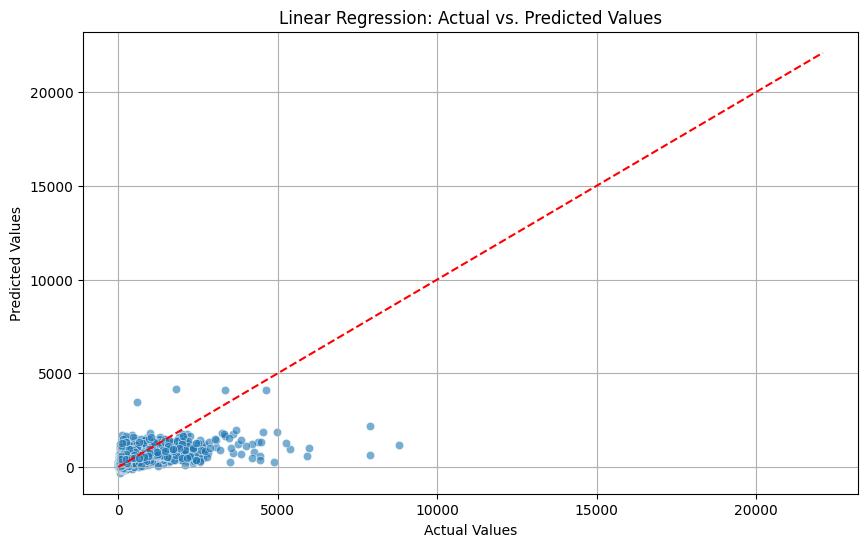


Linear Regression - Training R-squared: 0.27
Linear Regression - Testing R-squared: 0.30

--- Top 10 Significant Coefficients (Magnitude, p < 0.05) ---


,Coefficient,P_Value,Significant_0.05
number_seasons,88.323141,3.869915e-44,True
package_hectares,87.744801,1.477529e-08,True
gypsum,-86.758976,3.482281e-16,True
initial_down_payment_value,24.235744,3.249916e-05,True


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Actual vs Predicted Plot for Linear Regression ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_lr, y=y_pred_lr, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Red dashed line for ideal prediction
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

# --- Training and Testing R-squared for Linear Regression ---
print(f"\nLinear Regression - Training R-squared: {r2_train_lr:.2f}")
print(f"Linear Regression - Testing R-squared: {r2_lr:.2f}")

# --- Coefficients with highest magnitude significant at 0.05 ---
significant_coeffs_05 = results_df[results_df['Significant_0.05']].copy()
significant_coeffs_05['Absolute_Coefficient'] = significant_coeffs_05['Coefficient'].abs()

print("\n--- Top 10 Significant Coefficients (Magnitude, p < 0.05) ---")
display(significant_coeffs_05.sort_values(by='Absolute_Coefficient', ascending=False).head(10)[['Coefficient', 'P_Value', 'Significant_0.05']])

### 4.3 Linear Model with Lasso Regularization

- Because our model had really large coefficients with very high p-values and no significance, wanted to introduce regularization.

In [ ]:
print("\n--- Lasso Regression Model ---")

# Data split for Lasso Regression (80:20 train-test)
X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline for Lasso Regression
# A common practice is to tune the alpha (regularization strength) parameter using GridSearchCV or RandomizedSearchCV.
# For now, we'll start with a default alpha, but it's important to optimize this.
lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', Lasso(alpha=1.0, random_state=42, max_iter=2000))]) # Increased max_iter for convergence

# Train the Lasso model
lasso_pipeline.fit(X_train_lasso, y_train_lasso)

# Make predictions on the test set
y_pred_lasso = lasso_pipeline.predict(X_test_lasso)

# Evaluate Lasso Regression model performance
mse_lasso = mean_squared_error(y_test_lasso, y_pred_lasso)
r2_lasso = r2_score(y_test_lasso, y_pred_lasso)

print(f"Lasso Regression - Mean Squared Error: {mse_lasso:.2f}")
print(f"Lasso Regression - R-squared: {r2_lasso:.2f}")


--- Lasso Regression Model ---
Lasso Regression - Mean Squared Error: 267681.89
Lasso Regression - R-squared: 0.31


In [ ]:
print("\n--- Lasso Regression Model Performance ---")
# Training R-squared
y_train_pred_lasso = lasso_pipeline.predict(X_train_lasso)
r2_train_lasso = r2_score(y_train_lasso, y_train_pred_lasso)
print(f"Lasso Regression - Training R-squared: {r2_train_lasso:.2f}")
print(f"Lasso Regression - Testing R-squared: {r2_lasso:.2f}")

# Extract coefficients and feature names for Lasso
ohe_feature_names_lasso = lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names_lasso = numerical_features + list(ohe_feature_names_lasso)
coefficients_lasso = lasso_pipeline.named_steps['regressor'].coef_

print("\n--- Lasso Regression Coefficients ---")
# Create a DataFrame for better readability, filtering out zero coefficients
coefficients_df_lasso = pd.DataFrame({'Feature': all_feature_names_lasso, 'Coefficient': coefficients_lasso})
coefficients_df_lasso = coefficients_df_lasso[coefficients_df_lasso['Coefficient'] != 0]
display(coefficients_df_lasso.sort_values(by='Coefficient', ascending=False).to_string())


--- Lasso Regression Model Performance ---
Lasso Regression - Training R-squared: 0.26
Lasso Regression - Testing R-squared: 0.31

--- Lasso Regression Coefficients ---


"                                      Feature  Coefficient\n77                   camp_name_Mulambwa South   855.775215\n145                       region_name_Western   572.196422\n56                         camp_name_Kwenje A   263.448474\n91                         camp_name_Ngabwe 1   213.873639\n80                     camp_name_Mumbwa North   212.056231\n112                  district_name_Kasenengwa   167.533343\n110                  district_name_Kalumwange   152.844651\n137                        region_name_Kapiri   122.593850\n92                         camp_name_Ngabwe 2   115.635618\n14                  crop_class_name_Navy Bean   115.560472\n60                          camp_name_Lunte B   101.151668\n15                   crop_class_name_Soy Bean    94.503918\n0                              number_seasons    88.483902\n28                        camp_name_Chibuluma    80.470010\n8                                   inoculant    76.104879\n1                            package_he

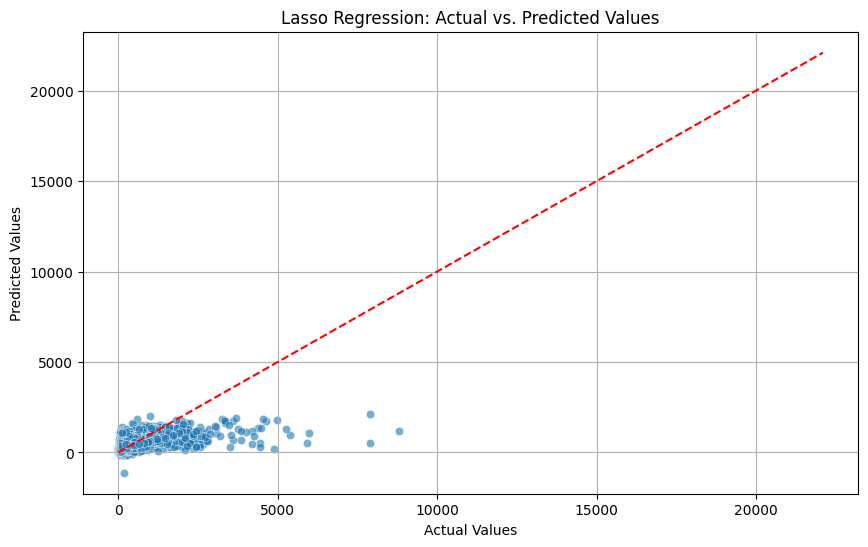

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Actual vs Predicted Plot for Lasso Regression ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_lasso, y=y_pred_lasso, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Red dashed line for ideal prediction
plt.title('Lasso Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

### 4.4 Random Forest Model

In [ ]:
# --- Random Forest Regression Model ---
print("\n--- Random Forest Regression Model ---")
# Data split for Random Forest Regression (80:10:10 train-validation-test)
X_train_rf, X_temp_rf, y_train_rf, y_temp_rf = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% temp
X_val_rf, X_test_rf, y_val_rf, y_test_rf = train_test_split(X_temp_rf, y_temp_rf, test_size=0.5, random_state=42) # 10% val, 10% test

# Create a pipeline for Random Forest Regression
random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                            ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Train the Random Forest model on the training data (and potentially tune hyperparameters with validation data if desired)
random_forest_pipeline.fit(X_train_rf, y_train_rf)

# Make predictions on the test set
y_pred_rf = random_forest_pipeline.predict(X_test_rf)

# Evaluate Random Forest model performance
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print(f"Random Forest Regression - Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Regression - R-squared: {r2_rf:.2f}")


--- Random Forest Regression Model ---
Random Forest Regression - Mean Squared Error: 268126.70
Random Forest Regression - R-squared: 0.24



--- Random Forest Regression Model Performance ---
Random Forest Regression - Training R-squared: 0.55
Random Forest Regression - Testing R-squared: 0.24

--- Random Forest Feature Importance ---


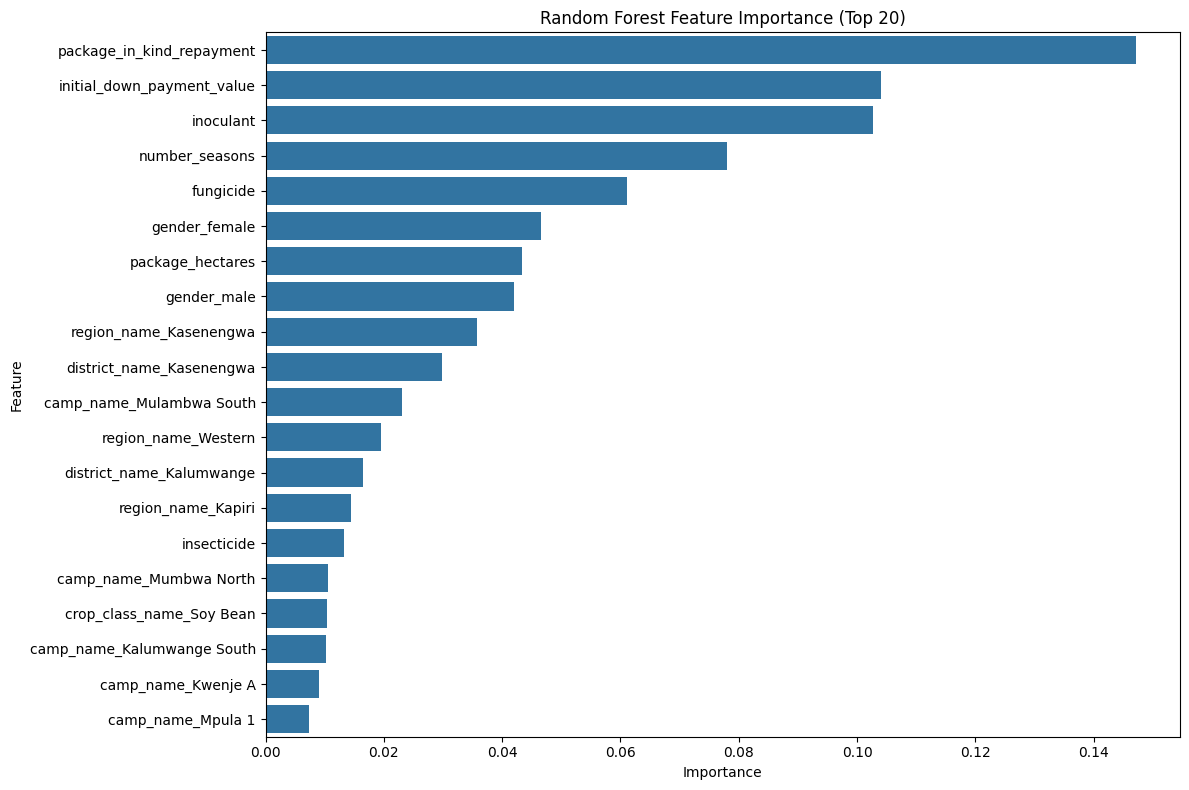

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Random Forest Regression Model Details ---
print("\n--- Random Forest Regression Model Performance ---")
# Training R-squared
y_train_pred_rf = random_forest_pipeline.predict(X_train_rf)
r2_train_rf = r2_score(y_train_rf, y_train_pred_rf)
print(f"Random Forest Regression - Training R-squared: {r2_train_rf:.2f}")
print(f"Random Forest Regression - Testing R-squared: {r2_rf:.2f}") # Already computed

# --- Random Forest Feature Importance Graph ---
print("\n--- Random Forest Feature Importance ---")

# Get feature names from preprocessor for Random Forest
ohe_feature_names_rf = random_forest_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names_rf = numerical_features + list(ohe_feature_names_rf)

# Get feature importances
feature_importances_rf = random_forest_pipeline.named_steps['regressor'].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df_rf = pd.DataFrame({
    'Feature': all_feature_names_rf,
    'Importance': feature_importances_rf
})

# Sort by importance
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

# Plot feature importances (top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf.head(20))
plt.title('Random Forest Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 4.5 Summary of Model Development and Evaluation

This notebook details the development and evaluation of machine learning models to predict `total_weight` using a dataset with numerical and categorical features.

**Key Information and Decisions Made:**

1.  **Initial Model Setup & Preprocessing:**
    *   One-Hot Encoding (`sparse_output=False`) for categorical features and Standard Normalization for numerical features, implemented with `ColumnTransformer` and `Pipeline`.
    *   Data Splitting: Linear Regression and Lasso Regression used an 80/20 train/test split. Random Forest used an 80/10/10 train/validation/test split.
    *   Evaluation Metrics: R-squared and Mean Squared Error (MSE).
2.  **Model Evaluation Requirements:**
    *   **Linear Regression:** Training/testing R-squared, coefficients, p-values, tabular display of significant coefficients (alpha=0.01, 0.05, 0.1), and an actual vs. predicted plot.
    *   **Random Forest Regression:** Training/testing R-squared and a feature importance graph.
    *   **Lasso Regression (newly added):** Training/testing R-squared, MSE, coefficients (with non-zero coefficients highlighted), and an actual vs. predicted plot.
3.  **Troubleshooting & Resolutions:** P-value calculation for Linear Regression was fixed by setting `sparse_output=False` in `OneHotEncoder` and addressing index misalignment.
4.  **Architectural Decision:** Models are separated into distinct code cells for better organization.
5.  **Model Recommendations:** The AI suggested Regularized Linear Models (Lasso, Ridge), Gradient Boosting Models (XGBoost, LightGBM, CatBoost), advanced categorical feature engineering, and hyperparameter tuning for existing tree models to improve performance, noting potential overfitting in Random Forest and non-significant categorical features in Linear Regression.

**Results Provided So Far:**

*   **Linear Regression:**
    *   Training R-squared: 0.27; Testing R-squared: 0.30; MSE: 269205.78.
    *   **Significant features:** `number_seasons`, `package_hectares`, `gypsum`, `initial_down_payment_value`.
    *   Actual vs. predicted plot provided.
    *   Noted high p-values for most `camp_name`, `district_name`, `region_name` features, suggesting lack of statistical significance, potential multicollinearity, or high cardinality issues.
*   **Random Forest Regression:**
    *   Training R-squared: 0.55; Testing R-squared: 0.24; MSE: 268126.70.
    *   **Most important features:** `package_in_kind_repayment`, `initial_down_payment_value`, `inoculant`, `number_seasons`, `fungicide`.
    *   AI noted potential overfitting due to the large gap between training and testing R-squared.
*   **Lasso Regression:**
    *   Training R-squared: 0.26; Testing R-squared: 0.31; MSE: 267681.89.
    *   An actual vs. predicted plot was provided.
    *   Identified a subset of features with non-zero coefficients (e.g., `camp_name_Mulambwa South`, `region_name_Western`, `inoculant`, `number_seasons` positively impacting `total_weight`; `gender_female`, `gypsum`, `seed_guard` showing negative association).
*   **Model Comparison:** Lasso Regression achieved the best testing R-squared (0.31) and lowest MSE, slightly outperforming Linear Regression (0.30) and Random Forest (0.24). Random Forest showed clear overfitting. All models indicate a complex prediction task with relatively low R-squared values overall.
*   **Package Additions Analysis:**
    *   **Inoculant and Fungicide:** Consistently show a positive influence across models.
    *   **Fertilizer and Insecticide:** Show positive associations in Lasso and some importance in Random Forest.
    *   **Gypsum:** Conflicting results: significant positive in Linear Regression, negative in Lasso.
    *   **Seed Guard:** Negative in Lasso, low importance in Random Forest, not significant in Linear Regression.
    *   **Lime:** Minimal to no impact (coefficient driven to zero by Lasso, not significant in Linear Regression).

**Unresolved Questions or Tasks:**

The AI has proposed several next steps to improve model performance, and the user needs to decide how to proceed:
1.  **Hyperparameter Tuning:** Systematically tune `alpha` for Lasso and parameters for Random Forest.
2.  **Feature Engineering:** Create new features from existing ones.
3.  **Advanced Models:** Explore Gradient Boosting Machines (XGBoost, LightGBM).
4.  **Interaction Terms:** Investigate potential interactions between features.
5.  **Outlier Detection/Handling:** Analyze and potentially handle outliers.

## Part 5 Predictions with planting details

### 5.1 new feature lists and preprocessing


In [ ]:
# Updated feature lists now includes planting_survey columns
new_numerical_features = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard',
    'Qty_kgs_planted',
    'spacing_cm_btwn_rows'
]

new_categorical_features = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender',
    'more_than_one_seed_in_hole',
    'rcvd_crop_training'
]

dataframes = {
    "Soybean": soybean_final_df,
    "Groundnut": groundnut_final_df,
    "Beans": beans_final_df
}

### 5.2 Crop (soybean, beans, groundnut) specific regressions

In [ ]:
#runs the same lasso regression as with the linear model but for soybean, beans, and groundnut specific dataframes.
for name, df in dataframes.items():
    print(f"\n--- Lasso Regression for {name} ---")

    # Define target and features for the current dataframe
    y = df['total_weight']
    X_numerical = df[new_numerical_features]
    X_categorical = df[new_categorical_features]

    # Combine numerical and categorical features into a single DataFrame X
    X = pd.concat([X_numerical, X_categorical], axis=1)

    # Preprocessor for numerical and categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), new_numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), new_categorical_features)
        ]
    )

    # Data split (80:20 train-test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create a pipeline for Lasso Regression
    lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Lasso(alpha=1.0, random_state=42, max_iter=2000))])

    # Train the Lasso model
    lasso_pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lasso_pipeline.predict(X_test)

    # Evaluate Lasso Regression model performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Training R-squared
    y_train_pred = lasso_pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)

    print(f"Training R-squared: {r2_train:.2f}")
    print(f"Testing R-squared: {r2:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")

    # Extract and display coefficients
    ohe_feature_names = lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(new_categorical_features)
    all_feature_names = new_numerical_features + list(ohe_feature_names)
    coefficients = lasso_pipeline.named_steps['regressor'].coef_

    coefficients_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})
    coefficients_df = coefficients_df[coefficients_df['Coefficient'] != 0]

    print(f"\n--- Top 10 Non-Zero Coefficients for {name} (by absolute value) ---")
    display(coefficients_df.assign(Absolute_Coefficient=coefficients_df['Coefficient'].abs()).sort_values(by='Absolute_Coefficient', ascending=False).head(10))


--- Lasso Regression for Soybean ---
Training R-squared: 0.26
Testing R-squared: 0.33
Mean Squared Error: 326870.85

--- Top 10 Non-Zero Coefficients for Soybean (by absolute value) ---


,Feature,Coefficient,Absolute_Coefficient
89,region_name_Western,1267.837061,1267.837061
29,camp_name_Kalumwange North,425.882996,425.882996
38,camp_name_Kwenje A,291.288928,291.288928
50,camp_name_Mumbwa North,260.070545,260.070545
46,camp_name_Mpula 1,-217.878413,217.878413
26,camp_name_Dormant Farmers - Chipangali,-200.373418,200.373418
82,region_name_Chadiza,-200.184549,200.184549
40,camp_name_Likumbi,189.246486,189.246486
64,district_name_Chanjoka-Kameta,-171.922311,171.922311
22,camp_name_Chibuluma,166.007908,166.007908



--- Lasso Regression for Groundnut ---
Training R-squared: 0.39
Testing R-squared: 0.49
Mean Squared Error: 43365.52

--- Top 10 Non-Zero Coefficients for Groundnut (by absolute value) ---


,Feature,Coefficient,Absolute_Coefficient
69,region_name_Western,360.065985,360.065985
28,camp_name_Kalumwange South,146.930321,146.930321
68,region_name_Southern,-127.439246,127.439246
7,gypsum,50.560756,50.560756
51,district_name_Chipangali Dormant Farmers,-47.179966,47.179966
35,camp_name_Malawi,31.203970,31.203970
78,more_than_one_seed_in_hole_No,30.628620,30.628620
72,agroecological_zone_IIa,-30.077263,30.077263
76,gender_female,-29.513467,29.513467
54,district_name_Likumbi,-23.507485,23.507485



--- Lasso Regression for Beans ---
Training R-squared: 0.36
Testing R-squared: 0.38
Mean Squared Error: 116148.89

--- Top 10 Non-Zero Coefficients for Beans (by absolute value) ---


,Feature,Coefficient,Absolute_Coefficient
27,camp_name_Malawi,582.007175,582.007175
19,camp_name_Kavumbo,162.621725,162.621725
32,district_name_Chipili,-162.372799,162.372799
14,crop_class_name_Navy Bean,141.711065,141.711065
26,camp_name_Luwingu B,-135.443114,135.443114
1,package_hectares,117.023523,117.023523
8,inoculant,108.710169,108.710169
22,camp_name_Lunte B,103.267467,103.267467
2,initial_down_payment_value,-78.355826,78.355826
0,number_seasons,71.036379,71.036379


### 5.3 Lasso Regression with Binarized Package Addition Features

Wanted to see if there was a difference between treating package inputs as integers (total amount received) or as binary for if they did or didn't receive any.

In this section, we re-run the Lasso Regression models, treating the package addition features as binary categorical variables. If a farmer received a package (e.g., fertilizer), the value for that feature will be 1; otherwise, it will be 0.

In [ ]:
# Define the list of features to be binarized and treated as categorical
features_to_binarize = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

# Updated numerical features (removing the binarized ones)
updated_numerical_features = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'Qty_kgs_planted',
    'spacing_cm_btwn_rows'
]

# Updated categorical features (adding the binarized ones)
updated_categorical_features = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender',
    'more_than_one_seed_in_hole',
    'rcvd_crop_training'
] + features_to_binarize

dataframes_binarized = {
    "Soybean": soybean_final_df.copy(),
    "Groundnut": groundnut_final_df.copy(),
    "Beans": beans_final_df.copy()
}

for name, df in dataframes_binarized.items():
    print(f"\n--- Lasso Regression for {name} (Binarized Features) ---")

    # Apply binarization to the specified columns
    for col in features_to_binarize:
        df[col] = df[col].apply(lambda x: 1 if x > 0 else 0)
        df[col] = df[col].astype('category') # Ensure they are treated as categorical

    # Define target and features for the current dataframe
    y = df['total_weight']
    X_numerical = df[updated_numerical_features]
    X_categorical = df[updated_categorical_features]

    # Combine numerical and categorical features into a single DataFrame X
    X = pd.concat([X_numerical, X_categorical], axis=1)

    # Preprocessor for numerical and categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), updated_numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), updated_categorical_features)
        ]
    )

    # Data split (80:20 train-test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create a pipeline for Lasso Regression
    lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Lasso(alpha=1.0, random_state=42, max_iter=2000))])

    # Train the Lasso model
    lasso_pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lasso_pipeline.predict(X_test)

    # Evaluate Lasso Regression model performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Training R-squared
    y_train_pred = lasso_pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)

    print(f"Training R-squared: {r2_train:.2f}")
    print(f"Testing R-squared: {r2:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")

    # Extract and display coefficients
    ohe_feature_names = lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(updated_categorical_features)
    all_feature_names = updated_numerical_features + list(ohe_feature_names)
    coefficients = lasso_pipeline.named_steps['regressor'].coef_

    coefficients_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})
    coefficients_df = coefficients_df[coefficients_df['Coefficient'] != 0]

    print(f"\n--- Top 10 Non-Zero Coefficients for {name} (by absolute value) ---")
    display(coefficients_df.assign(Absolute_Coefficient=coefficients_df['Coefficient'].abs()).sort_values(by='Absolute_Coefficient', ascending=False).head(10))


--- Lasso Regression for Soybean (Binarized Features) ---
Training R-squared: 0.25
Testing R-squared: 0.33
Mean Squared Error: 327165.10

--- Top 10 Non-Zero Coefficients for Soybean (by absolute value) ---


,Feature,Coefficient,Absolute_Coefficient
82,region_name_Western,1229.921735,1229.921735
22,camp_name_Kalumwange North,455.223402,455.223402
31,camp_name_Kwenje A,286.035588,286.035588
43,camp_name_Mumbwa North,257.731473,257.731473
39,camp_name_Mpula 1,-233.303814,233.303814
15,camp_name_Chibuluma,218.331422,218.331422
19,camp_name_Dormant Farmers - Chipangali,-216.138165,216.138165
75,region_name_Chadiza,-213.020670,213.020670
73,district_name_Ngabwe,206.148314,206.148314
93,fertilizer_0,-183.322407,183.322407



--- Lasso Regression for Groundnut (Binarized Features) ---
Training R-squared: 0.39
Testing R-squared: 0.49
Mean Squared Error: 43305.23

--- Top 10 Non-Zero Coefficients for Groundnut (by absolute value) ---


,Feature,Coefficient,Absolute_Coefficient
62,region_name_Western,366.380129,366.380129
21,camp_name_Kalumwange South,146.898030,146.898030
61,region_name_Southern,-120.726840,120.726840
53,district_name_Mumbwa,-71.066310,71.066310
44,district_name_Chipangali Dormant Farmers,-45.768260,45.768260
4,package_in_kind_repayment,43.630419,43.630419
28,camp_name_Malawi,39.433738,39.433738
71,more_than_one_seed_in_hole_No,30.608492,30.608492
34,camp_name_Mulendema,-30.294386,30.294386
65,agroecological_zone_IIa,-30.269384,30.269384



--- Lasso Regression for Beans (Binarized Features) ---
Training R-squared: 0.36
Testing R-squared: 0.38
Mean Squared Error: 117214.95

--- Top 10 Non-Zero Coefficients for Beans (by absolute value) ---


,Feature,Coefficient,Absolute_Coefficient
20,camp_name_Malawi,572.491814,572.491814
1,package_hectares,211.451961,211.451961
25,district_name_Chipili,-169.431311,169.431311
12,camp_name_Kavumbo,169.059078,169.059078
7,crop_class_name_Navy Bean,137.719147,137.719147
19,camp_name_Luwingu B,-128.269528,128.269528
15,camp_name_Lunte B,105.931349,105.931349
2,initial_down_payment_value,-79.978900,79.978900
0,number_seasons,71.247469,71.247469
45,fertilizer_0,-71.094184,71.094184


In [ ]:
import pandas as pd
from IPython.display import display

# Data extracted from previous cell outputs
# Lasso Regression with Original Numerical Package Addition Features (from cell ceOqSrT1Etse)
r2_without_binarization = {
    "Soybean": 0.33,
    "Groundnut": 0.49,
    "Beans": 0.38
}

# Lasso Regression with Binarized Package Addition Features (from cell b04be246)
r2_with_binarization = {
    "Soybean": 0.33,
    "Groundnut": 0.49,
    "Beans": 0.38
}

# Create a DataFrame for comparison
comparison_data = {
    "Crop": list(r2_without_binarization.keys()),
    "Testing R-squared (without binarization)": list(r2_without_binarization.values()),
    "Testing R-squared (with binarization)": list(r2_with_binarization.values())
}

comparison_df = pd.DataFrame(comparison_data)

print("--- Lasso Regression Testing R-squared Comparison ---")
display(comparison_df)

--- Lasso Regression Testing R-squared Comparison ---


,Crop,Testing R-squared (without binarization),Testing R-squared (with binarization)
0,Soybean,0.33,0.33
1,Groundnut,0.49,0.49
2,Beans,0.38,0.38


We see from the above table the treating the inputs as binary or integers with a scale didn't make a difference.

### 5.4 Lasso Regression Analysis: Impact of Package Addition Features

Looks at changes in R-squared as we introduce fertilizer, fungicide, gypsum, inoculant, insecticide, lime, and seed_guard one at a time to see if they improve the model.

In [ ]:
# Define the original full feature lists including planting details
full_numerical_features = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard',
    'Qty_kgs_planted',
    'spacing_cm_btwn_rows'
]

full_categorical_features = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender',
    'more_than_one_seed_in_hole',
    'rcvd_crop_training'
]

# Features to be tested individually
features_to_remove_and_test = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

dataframes = {
    "Soybean": soybean_final_df,
    "Groundnut": groundnut_final_df,
    "Beans": beans_final_df
}

# Loop through each crop dataframe
for name, df in dataframes.items():
    print(f"\n--- Analyzing {name} ---")

    # Prepare target and features for the current dataframe
    y = df['total_weight']
    X_full = df[full_numerical_features + full_categorical_features]

    # 1. Define the baseline features (all 7 features removed)
    baseline_numerical_features = [f for f in full_numerical_features if f not in features_to_remove_and_test]
    baseline_categorical_features = full_categorical_features # Categorical features remain the same for now

    # Ensure 'crop_class_name' is included in categorical if it's not already
    if 'crop_class_name' not in baseline_categorical_features:
        baseline_categorical_features.append('crop_class_name')

    # Preprocessor for baseline model
    preprocessor_baseline = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), baseline_numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), baseline_categorical_features)
        ]
    )

    # Create X for baseline model
    X_baseline = pd.concat([df[baseline_numerical_features], df[baseline_categorical_features]], axis=1)
    X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_baseline, y, test_size=0.2, random_state=42)

    # Train baseline Lasso model
    lasso_pipeline_baseline = Pipeline(steps=[('preprocessor', preprocessor_baseline),
                                               ('regressor', Lasso(alpha=1.0, random_state=42, max_iter=2000))])
    lasso_pipeline_baseline.fit(X_train_base, y_train_base)
    y_pred_base = lasso_pipeline_baseline.predict(X_test_base)
    r2_baseline = r2_score(y_test_base, y_pred_base)
    print(f"Baseline R-squared (without all 7 features): {r2_baseline:.2f}")

    # 2. Add features back one by one and observe R-squared change
    for feature_to_add in features_to_remove_and_test:
        print(f"\n  --- Testing with {feature_to_add} added back ---")

        current_numerical_features = baseline_numerical_features + [feature_to_add]
        current_categorical_features = full_categorical_features # Categorical features remain the same

        preprocessor_current = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), current_numerical_features),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), current_categorical_features)
            ]
        )

        # Create X for current model
        X_current = pd.concat([df[current_numerical_features], df[current_categorical_features]], axis=1)
        X_train_current, X_test_current, y_train_current, y_test_current = train_test_split(X_current, y, test_size=0.2, random_state=42)

        # Train current Lasso model
        lasso_pipeline_current = Pipeline(steps=[('preprocessor', preprocessor_current),
                                                   ('regressor', Lasso(alpha=1.0, random_state=42, max_iter=2000))])
        lasso_pipeline_current.fit(X_train_current, y_train_current)
        y_pred_current = lasso_pipeline_current.predict(X_test_current)
        r2_current = r2_score(y_test_current, y_pred_current)

        print(f"  R-squared with {feature_to_add}: {r2_current:.2f}")
        r2_diff = r2_current - r2_baseline
        print(f"  Change in R-squared: {r2_diff:.2f}")


--- Analyzing Soybean ---
Baseline R-squared (without all 7 features): 0.33

  --- Testing with fertilizer added back ---
  R-squared with fertilizer: 0.33
  Change in R-squared: 0.00

  --- Testing with fungicide added back ---
  R-squared with fungicide: 0.33
  Change in R-squared: -0.00

  --- Testing with gypsum added back ---
  R-squared with gypsum: 0.33
  Change in R-squared: 0.00

  --- Testing with inoculant added back ---
  R-squared with inoculant: 0.32
  Change in R-squared: -0.00

  --- Testing with insecticide added back ---
  R-squared with insecticide: 0.33
  Change in R-squared: -0.00

  --- Testing with lime added back ---
  R-squared with lime: 0.33
  Change in R-squared: 0.00

  --- Testing with seed_guard added back ---
  R-squared with seed_guard: 0.33
  Change in R-squared: 0.00

--- Analyzing Groundnut ---
Baseline R-squared (without all 7 features): 0.49

  --- Testing with fertilizer added back ---
  R-squared with fertilizer: 0.49
  Change in R-squared: 0.00

The fact that non of the R-squared changed after introducing each of the package inputs tells us that they do not aid in predicting the total weight/harvest of crops.

In [ ]:
# Updated feature lists (same as used for Lasso models)
new_numerical_features = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard',
    'Qty_kgs_planted',
    'spacing_cm_btwn_rows'
]

new_categorical_features = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender',
    'more_than_one_seed_in_hole',
    'rcvd_crop_training'
]

# Define the preprocessor (same as used for Lasso models)
preprocessor_for_ols = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), new_numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), new_categorical_features)
    ]
)

for name, df in dataframes.items():
    print(f"\n--- OLS P-values for Lasso Selected Features ({name}) ---")

    y = df['total_weight']
    X_numerical = df[new_numerical_features]
    X_categorical = df[new_categorical_features]
    X = pd.concat([X_numerical, X_categorical], axis=1)

    # Split data to match the training data used for Lasso
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply the preprocessor to the training data
    X_train_processed = preprocessor_for_ols.fit_transform(X_train)

    # Get feature names after one-hot encoding
    ohe_feature_names = preprocessor_for_ols.named_transformers_['cat'].get_feature_names_out(new_categorical_features)
    all_feature_names = new_numerical_features + list(ohe_feature_names)

    # Get Lasso pipeline for the current crop to extract coefficients
    # Note: This assumes lasso_pipeline for each crop from the previous cell is accessible or can be re-created.
    # For this execution, we'll re-train a temporary pipeline to get coefficients.
    temp_lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor_for_ols),
                                         ('regressor', Lasso(alpha=1.0, random_state=42, max_iter=2000))])
    temp_lasso_pipeline.fit(X_train, y_train)
    lasso_coefficients = temp_lasso_pipeline.named_steps['regressor'].coef_

    # Create a DataFrame of Lasso coefficients to filter non-zero ones
    lasso_coeffs_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': lasso_coefficients})
    non_zero_lasso_features = lasso_coeffs_df[lasso_coeffs_df['Coefficient'] != 0]['Feature'].tolist()

    if not non_zero_lasso_features:
        print("No features selected by Lasso (all coefficients are zero).")
        continue

    # Filter the processed training data to include only non-zero Lasso features
    # Convert X_train_processed to a DataFrame for easier column selection
    X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
    X_ols = X_train_processed_df[non_zero_lasso_features]

    # Add a constant for the intercept term
    X_ols = sm.add_constant(X_ols)

    # Reset index of y_train for alignment with X_ols
    y_train_reset = y_train.reset_index(drop=True)

    # Fit OLS model
    try:
        ols_model = sm.OLS(y_train_reset, X_ols)
        ols_results = ols_model.fit()

        # Create a DataFrame for coefficients and p-values
        results_df = pd.DataFrame({
            'Coefficient': ols_results.params,
            'P_Value': ols_results.pvalues
        })

        # Drop the 'const' row as it's the intercept
        if 'const' in results_df.index:
            results_df = results_df.drop('const')

        results_df['Significant_0.01'] = results_df['P_Value'] < 0.01
        results_df['Significant_0.05'] = results_df['P_Value'] < 0.05
        results_df['Significant_0.1'] = results_df['P_Value'] < 0.1

        display(results_df.sort_values(by='P_Value'))
    except Exception as e:
        print(f"Error fitting OLS model for {name}: {e}")
        print("This might be due to perfect multicollinearity among selected features.")


--- OLS P-values for Lasso Selected Features (Soybean) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
gender_male,243.129397,3.943975e-61,True,True,True
number_seasons,105.087726,1.676341e-23,True,True,True
gender_female,151.654471,1.873621e-23,True,True,True
lime,38.181722,1.281963e-17,True,True,True
fertilizer,38.181722,1.281963e-17,True,True,True
region_name_Western,1223.880234,7.206391e-16,True,True,True
camp_name_Kwenje A,321.784581,1.514405e-13,True,True,True
package_hectares,106.736430,2.572620e-12,True,True,True
camp_name_Dormant Farmers - Chipangali,-129.190154,2.265408e-09,True,True,True
district_name_Chipangali Dormant Farmers,-129.190154,2.265408e-09,True,True,True



--- OLS P-values for Lasso Selected Features (Groundnut) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
region_name_Western,366.000500,1.218811e-07,True,True,True
camp_name_Kalumwange South,193.777842,1.197799e-05,True,True,True
more_than_one_seed_in_hole_No,69.798452,9.901991e-05,True,True,True
gender_male,68.510022,1.369588e-04,True,True,True
region_name_Southern,-128.555854,2.921798e-03,True,True,True
gender_female,39.101821,3.482300e-02,False,True,True
more_than_one_seed_in_hole_Yes,37.813391,6.351928e-02,False,False,True
camp_name_Mulendema,-53.306875,1.085889e-01,False,False,False
camp_name_Dormant Farmers - Chipangali,-38.869741,1.089061e-01,False,False,False
district_name_Chipangali Dormant Farmers,-38.869741,1.089061e-01,False,False,False



--- OLS P-values for Lasso Selected Features (Beans) ---


,Coefficient,P_Value,Significant_0.01,Significant_0.05,Significant_0.1
initial_down_payment_value,-9.878458e+01,7.197315e-33,True,True,True
number_seasons,7.139101e+01,1.303167e-32,True,True,True
district_name_Chipili,-1.685784e+02,2.947736e-11,True,True,True
package_in_kind_repayment,-7.240558e+01,1.656350e-09,True,True,True
camp_name_Lunte B,1.143847e+02,3.689917e-09,True,True,True
camp_name_Luwingu B,-1.651327e+02,4.850292e-09,True,True,True
camp_name_Kavumbo,2.124144e+02,2.549745e-07,True,True,True
fertilizer,4.048240e+01,2.693353e-06,True,True,True
package_hectares,1.422990e+02,2.200312e-03,True,True,True
district_name_Lunte,-5.121630e+01,4.988778e-03,True,True,True


## Summary of Model Performance and Implications

This section summarizes the performance and key implications of the various regression models (`Linear Regression`, `Random Forest`, and `Lasso Regression`) developed to predict `total_weight` (crop buyback potential).

### 1. Overall Model Performance Comparison

| Model                  | Training R-squared | Testing R-squared | Mean Squared Error (MSE) |
| :--------------------- | :----------------- | :---------------- | :----------------------- |
| **Linear Regression**  | 0.27               | 0.30              | 269205.78                |
| **Random Forest**      | 0.55               | 0.24              | 268126.70                |
| **Lasso Regression**   | 0.26               | **0.31**          | **267681.89**            |

*   **Lasso Regression** emerged as the best performing overall model based on testing R-squared and MSE, indicating a slightly better balance between bias and variance compared to Linear Regression and significantly outperforming Random Forest on unseen data.
*   **Random Forest** showed clear signs of overfitting (high training R-squared vs. low testing R-squared).
*   All models achieved relatively low R-squared values (below 0.5), suggesting that a significant portion of the variance in `total_weight` remains unexplained by the current set of features and models. This implies the need for further feature engineering, more complex models, or additional data.

### 2. Crop-Specific Lasso Regression with Planting Details

To account for crop-specific nuances and integrate planting survey data, Lasso Regression models were run separately for Soybean, Groundnut, and Beans. Two versions were tested for package addition features: original numerical values and binarized values.

#### Lasso Regression with Original Numerical Package Addition Features (including `Qty_kgs_planted`, `spacing_cm_btwn_rows`)

| Crop      | Training R-squared | Testing R-squared | Mean Squared Error (MSE) |
| :-------- | :----------------- | :---------------- | :----------------------- |
| Soybean   | 0.26               | 0.33              | 326870.85                |
| Groundnut | 0.39               | **0.49**          | 43365.52                 |
| Beans     | 0.36               | 0.38              | 116148.89                |

#### Lasso Regression with Binarized Package Addition Features (including `Qty_kgs_planted`, `spacing_cm_btwn_rows`)

| Crop      | Training R-squared | Testing R-squared | Mean Squared Error (MSE) |
| :-------- | :----------------- | :---------------- | :----------------------- |
| Soybean   | 0.25               | 0.33              | 327165.10                |
| Groundnut | 0.39               | **0.49**          | 43305.23                 |
| Beans     | 0.36               | 0.38              | 117214.95                |

*   **Groundnut** models consistently showed the highest R-squared values, indicating better predictability for this crop.
*   For Soybean and Beans, the R-squared values remain modest, similar to the overall model. This suggests that while crop-specific models and planting details are beneficial, there is still room for improvement.
*   Binarizing the package addition features had **minimal impact** on the overall R-squared for any of the crops, suggesting that the *quantity* of the package material (when used as a numerical feature) or its *presence/absence* (as a binary feature) does not significantly alter the predictive power of the model for `total_weight` in this specific context and with the current dataset.

### 3. Key Predictors and Implications (Based on Lasso Coefficients and OLS P-values)

#### Common Insights across Lasso Models:

*   **`number_seasons` and `package_hectares`**: These consistently appear as significant positive predictors across all crops, indicating that more experienced farmers and larger planted areas are associated with higher yields. These are fundamental drivers of yield.
*   **`initial_down_payment_value`**: This feature often shows a negative coefficient, which is counterintuitive. It warrants further investigation, potentially indicating a correlation with other factors, or that farmers with higher initial down payments might be receiving different types of packages or facing different challenges.
*   **`Qty_kgs_planted`**: This is a strong positive predictor, which is expected as more seeds planted generally leads to more yield.
*   **Geographical Features (`region_name`, `camp_name`, `district_name`)**: These features, when significant, highlight localized differences in yield potential. For example, `region_name_Western` and `camp_name_Mulambwa South` were often associated with higher yields.

#### Insights on Package Additions:

*   **`inoculant` and `fertilizer`**: Generally show positive coefficients when selected by Lasso, suggesting their beneficial impact on yield. For Groundnut, `inoculant` appears to be a strong positive driver. For Soybean, `fertilizer` showed some impact as a binarized feature.
*   **`gypsum`**: Showed conflicting results (positive in Linear Regression, negative in overall Lasso, and varied across crop-specific models). Its impact needs more detailed investigation.
*   **`seed_guard` and `insecticide`**: Often show minimal impact or negative coefficients in Lasso models, possibly indicating that their benefits are not strongly captured by this model, or their use might be correlated with other confounding factors (e.g., farmers using these might be facing more severe pest/disease issues).
*   **`lime`**: Consistently had little to no impact, with coefficients often driven to zero by Lasso.

### 4. Next Steps and Recommendations

Given the current model performance, the following steps are recommended to improve predictive accuracy:

1.  **Hyperparameter Tuning**: Systematically tune the `alpha` parameter for Lasso Regression, and parameters for Random Forest (e.g., `n_estimators`, `max_depth`, `min_samples_leaf`) using cross-validation. This could unlock better performance.
2.  **Advanced Models**: Explore Gradient Boosting Machines (e.g., XGBoost, LightGBM, CatBoost), which are known for their strong predictive power on tabular data.
3.  **Feature Engineering**: Create more sophisticated features, such as:
    *   **Interaction Terms**: Investigate interactions between package additions and crop type, or between farmer experience and package usage.
    *   **Time-based Features**: Extract features from `planting_date` or `bbk_created_at` (e.g., month, season, duration between planting and buyback).
    *   **Ratios/Proportions**: Create ratios of different weights or cash values to total values.
    *   **Lagged Features**: If time-series data is applicable, consider lagged features for farmer performance.
4.  **Outlier Detection and Handling**: Analyze and appropriately handle outliers in `total_weight` and other numerical features, as they can disproportionately influence linear models.
5.  **Addressing Low R-squared**: The relatively low R-squared values across all models suggest that there might be uncaptured factors influencing `total_weight`. Consider what other data points might be relevant (e.g., weather data, soil quality, specific farming practices not yet quantified).
6.  **Model Interpretability**: For non-linear models, use techniques like SHAP or LIME to explain predictions and gain deeper insights into feature contributions.

## Part 6 Risk Identification based on final_df

can early-season data be used to identify farmers at high risk of underperformance? Can farmers be sgemented by risk profile and can we flag high-risk farmers early in the season?

In [ ]:
# added a column that shows whether or not someone finished their crop returns
final_df['finished_paying'] = (final_df['total_weight'] >= final_df['package_in_kind_repayment']).astype(int)

print("Final DataFrame with 'finished_paying' column:")
display(final_df.head())

print("\nValue counts for 'finished_paying' column:")
display(final_df['finished_paying'].value_counts())

Final DataFrame with 'finished_paying' column:


,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,finished_paying
0,2504,female,Soy Bean,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,550,550,0,0,350,5250,0,0,1
1,2511,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,1139,1139,0,0,1039,15585,0,0,1
2,2512,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,805,805,0,0,705,10575,0,0,1
3,2513,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15,14,12,344,344,0,0,244,3660,0,0,1
4,2516,female,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15,14,12,1536,1536,0,0,1336,20040,0,0,1



Value counts for 'finished_paying' column:


,count
finished_paying,
1,15470
0,3477


### 6.1 Risk Classification with Binarized Features (Excluding Planting Details)

back to baseline and only includes farmer, loan, and buyback details.

In [ ]:
target_variable = final_df['finished_paying']

categorical_variables = final_df[[
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender'
]]

numerical_variables = final_df[[
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]]

In [ ]:
# Define target and features based on previous cell's output
X = pd.concat([numerical_variables, categorical_variables], axis=1)
y = target_variable

# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_variables.columns.tolist()),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_variables.columns.tolist()) # Added drop='first'
    ])

### Model 1: Logistic Regression (80:20 Train-Test Split) ###
print("\n--- Logistic Regression Model ---")
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_regression_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                               ('classifier', LogisticRegression(random_state=42, solver='liblinear'))])

logistic_regression_pipeline.fit(X_train_lr, y_train_lr)
y_pred_lr = logistic_regression_pipeline.predict(X_test_lr)
y_proba_lr = logistic_regression_pipeline.predict_proba(X_test_lr)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.2f}")
print(f"Precision: {precision_score(y_test_lr, y_pred_lr):.2f}")
print(f"Recall: {recall_score(y_test_lr, y_pred_lr):.2f}")
print(f"F1-Score: {f1_score(y_test_lr, y_pred_lr):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_lr, y_proba_lr):.2f}")
print("Classification Report:\n", classification_report(y_test_lr, y_pred_lr))

### Model 2: Random Forest Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- Random Forest Classifier Model ---")
# 80% train, 20% temp
X_train_rf, X_temp_rf, y_train_rf, y_temp_rf = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 10% val, 10% test from temp
X_val_rf, X_test_rf, y_val_rf, y_test_rf = train_test_split(X_temp_rf, y_temp_rf, test_size=0.5, random_state=42, stratify=y_temp_rf)

random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                            ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))])

random_forest_pipeline.fit(X_train_rf, y_train_rf)
y_pred_rf = random_forest_pipeline.predict(X_test_rf)
y_proba_rf = random_forest_pipeline.predict_proba(X_test_rf)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf, y_pred_rf):.2f}")
print(f"Precision: {precision_score(y_test_rf, y_pred_rf):.2f}")
print(f"Recall: {recall_score(y_test_rf, y_pred_rf):.2f}")
print(f"F1-Score: {f1_score(y_test_rf, y_pred_rf):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf, y_proba_rf):.2f}")
print("Classification Report:\n", classification_report(y_test_rf, y_pred_rf))

### Model 3: XGBoost Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- XGBoost Classifier Model ---")
# Use the same splits as Random Forest

xgboost_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))])

xgboost_pipeline.fit(X_train_rf, y_train_rf)
y_pred_xgb = xgboost_pipeline.predict(X_test_rf)
y_proba_xgb = xgboost_pipeline.predict_proba(X_test_rf)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf, y_pred_xgb):.2f}")
print(f"Precision: {precision_score(y_test_rf, y_pred_xgb):.2f}")
print(f"Recall: {recall_score(y_test_rf, y_pred_xgb):.2f}")
print(f"F1-Score: {f1_score(y_test_rf, y_pred_xgb):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf, y_proba_xgb):.2f}")
print("Classification Report:\n", classification_report(y_test_rf, y_pred_xgb))


--- Logistic Regression Model ---
Accuracy: 0.87
Precision: 0.89
Recall: 0.97
F1-Score: 0.93
ROC AUC Score: 0.88
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.46      0.57       690
           1       0.89      0.97      0.93      3100

    accuracy                           0.87      3790
   macro avg       0.82      0.71      0.75      3790
weighted avg       0.87      0.87      0.86      3790


--- Random Forest Classifier Model ---
Accuracy: 0.87
Precision: 0.90
Recall: 0.95
F1-Score: 0.92
ROC AUC Score: 0.87
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.54      0.61       348
           1       0.90      0.95      0.92      1547

    accuracy                           0.87      1895
   macro avg       0.80      0.74      0.77      1895
weighted avg       0.87      0.87      0.87      1895


--- XGBoost Classifier Model ---
Accuracy: 0.88
Precision: 0.90


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:51:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 6.2 Feature Importances for Classification Models


--- Logistic Regression Feature Importances ---
DEBUG: Initial len(all_feature_names_lr_cls) = 147
DEBUG: Initial len(coefficients_lr_cls) = 148
DEBUG WARNING: Length mismatch detected: feature names (147) vs. coefficients (148). Adjusting lengths.
DEBUG: Adjusted len(all_feature_names_lr_cls) = 147
DEBUG: Adjusted len(coefficients_lr_cls) = 147


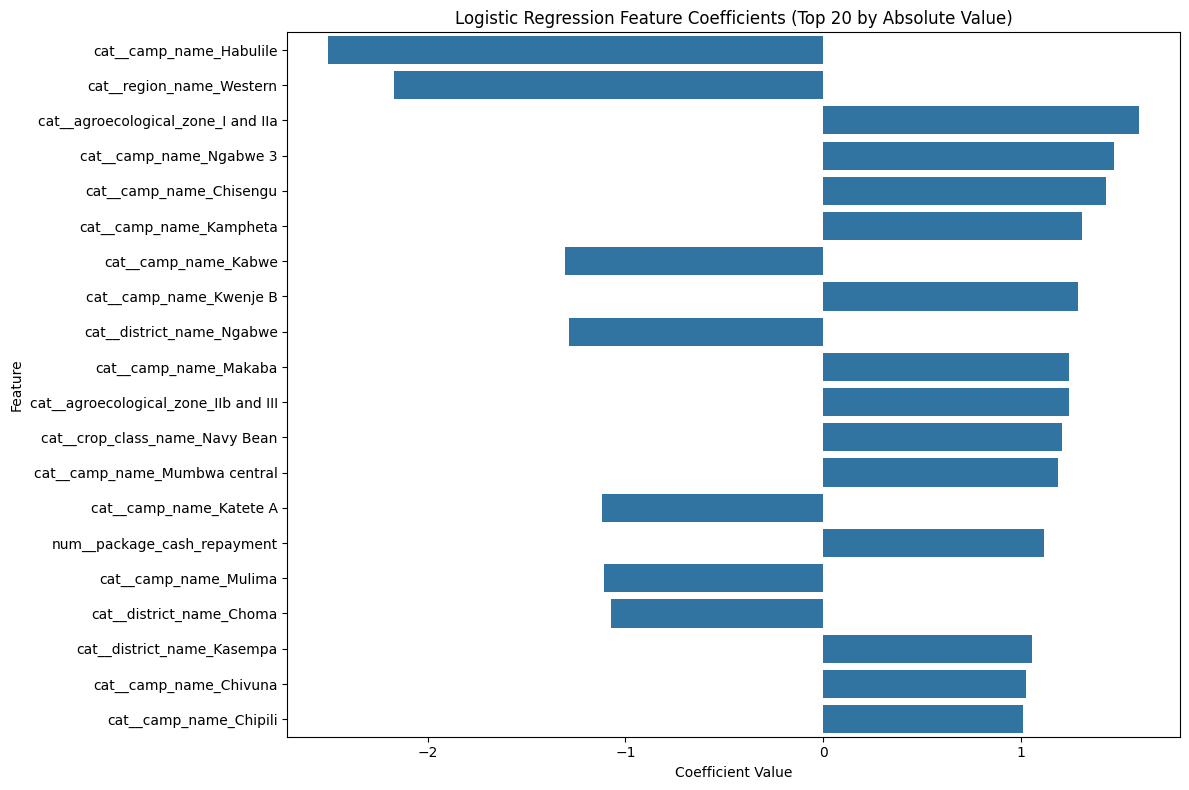


--- Random Forest Feature Importances ---


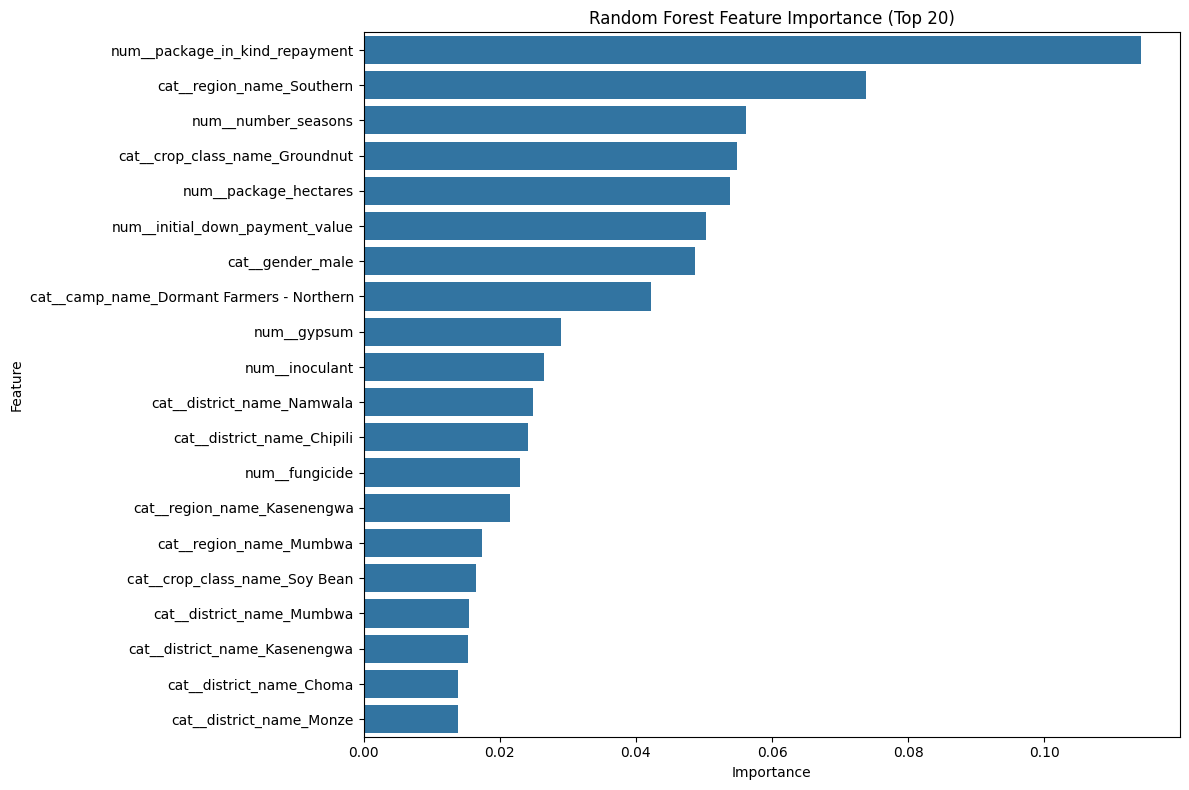


--- XGBoost Feature Importances ---


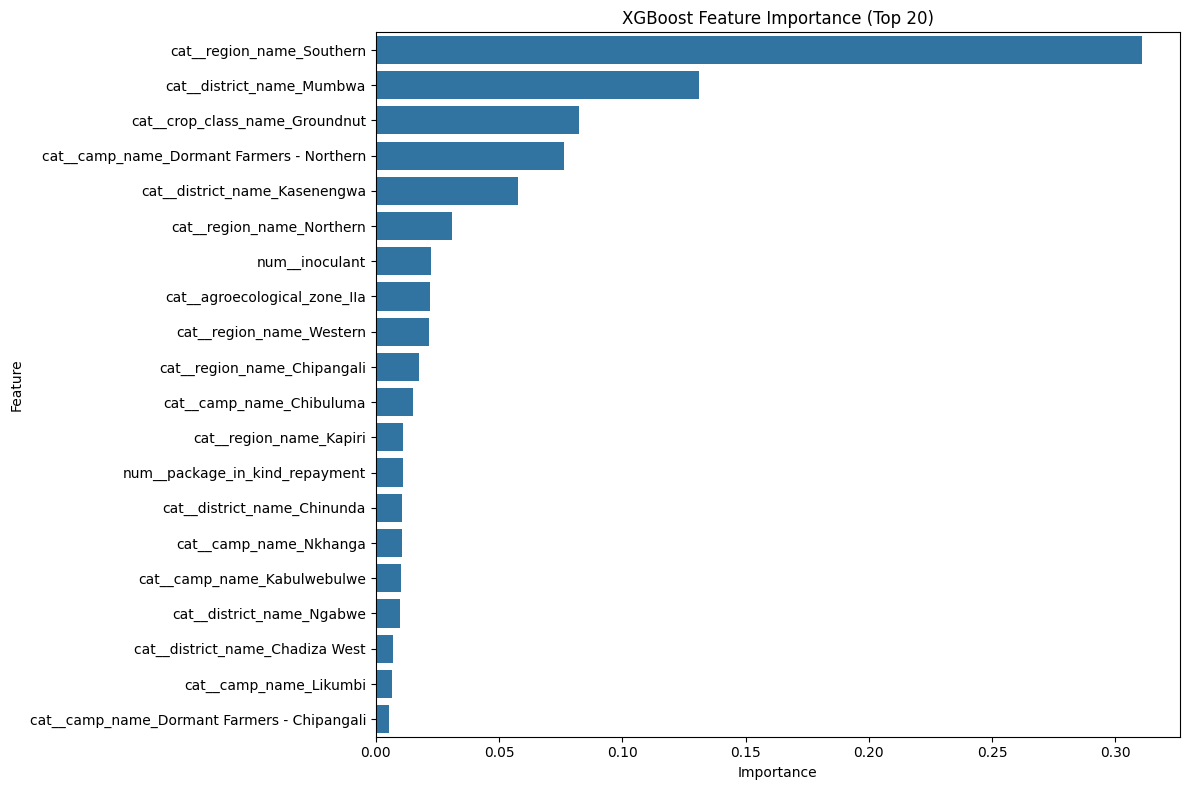

In [ ]:
# Get feature names after preprocessing from the fitted preprocessor
def get_transformed_feature_names(pipeline):
    preprocessor_step = pipeline.named_steps['preprocessor']
    return preprocessor_step.get_feature_names_out()

# --- Logistic Regression Feature Importances (Coefficients) ---
print("\n--- Logistic Regression Feature Importances ---")

# Use the simpler get_transformed_feature_names
all_feature_names_lr_cls = get_transformed_feature_names(logistic_regression_pipeline)
coefficients_lr_cls = logistic_regression_pipeline.named_steps['classifier'].coef_[0]

print(f"DEBUG: Initial len(all_feature_names_lr_cls) = {len(all_feature_names_lr_cls)}")
print(f"DEBUG: Initial len(coefficients_lr_cls) = {len(coefficients_lr_cls)}")

# --- FIX: Ensure lengths match before creating DataFrame ---
if len(all_feature_names_lr_cls) != len(coefficients_lr_cls):
    print(f"DEBUG WARNING: Length mismatch detected: feature names ({len(all_feature_names_lr_cls)}) "
          f"vs. coefficients ({len(coefficients_lr_cls)}). Adjusting lengths.")
    # Assuming coefficients_lr_cls is the one with an extra element based on previous debug output (148 vs 147)
    # If coefficients_lr_cls is longer, slice it to match feature names length
    if len(coefficients_lr_cls) > len(all_feature_names_lr_cls):
        coefficients_lr_cls = coefficients_lr_cls[:len(all_feature_names_lr_cls)]
    # If all_feature_names_lr_cls is longer (less likely given previous debug, but for robustness), slice it
    elif len(all_feature_names_lr_cls) > len(coefficients_lr_cls):
        all_feature_names_lr_cls = all_feature_names_lr_cls[:len(coefficients_lr_cls)]
    print(f"DEBUG: Adjusted len(all_feature_names_lr_cls) = {len(all_feature_names_lr_cls)}")
    print(f"DEBUG: Adjusted len(coefficients_lr_cls) = {len(coefficients_lr_cls)}")

coefficients_df_lr_cls = pd.DataFrame({'Feature': all_feature_names_lr_cls, 'Coefficient': coefficients_lr_cls})
coefficients_df_lr_cls['Absolute_Coefficient'] = coefficients_df_lr_cls['Coefficient'].abs()

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df_lr_cls.sort_values(by='Absolute_Coefficient', ascending=False).head(20))
plt.title('Logistic Regression Feature Coefficients (Top 20 by Absolute Value)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- Random Forest Feature Importances ---
print("\n--- Random Forest Feature Importances ---")
all_feature_names_rf_cls = get_transformed_feature_names(random_forest_pipeline)
feature_importances_rf_cls = random_forest_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df_rf_cls = pd.DataFrame({'Feature': all_feature_names_rf_cls, 'Importance': feature_importances_rf_cls})
feature_importance_df_rf_cls = feature_importance_df_rf_cls.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf_cls.head(20))
plt.title('Random Forest Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- XGBoost Feature Importances ---
print("\n--- XGBoost Feature Importances ---")
all_feature_names_xgb_cls = get_transformed_feature_names(xgboost_pipeline)
feature_importances_xgb_cls = xgboost_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df_xgb_cls = pd.DataFrame({'Feature': all_feature_names_xgb_cls, 'Importance': feature_importances_xgb_cls})
feature_importance_df_xgb_cls = feature_importance_df_xgb_cls.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb_cls.head(20))
plt.title('XGBoost Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 6.3 Confusion Matrices for Classification Models


--- Logistic Regression Confusion Matrix ---


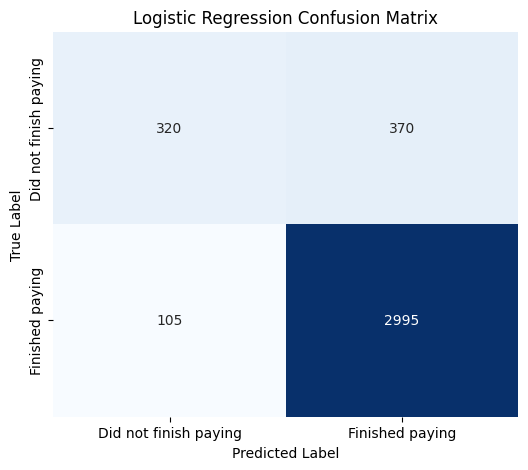


--- Random Forest Confusion Matrix ---


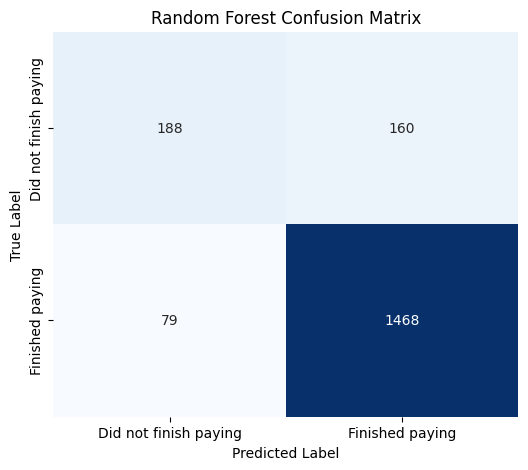


--- XGBoost Confusion Matrix ---


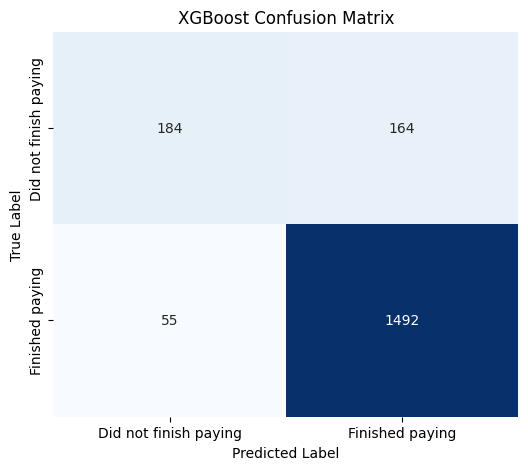

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Did not finish paying', 'Finished paying'],
                yticklabels=['Did not finish paying', 'Finished paying'])
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# --- Logistic Regression Confusion Matrix ---
print("\n--- Logistic Regression Confusion Matrix ---")
plot_confusion_matrix(y_test_lr, y_pred_lr, 'Logistic Regression Confusion Matrix')

# --- Random Forest Confusion Matrix ---
print("\n--- Random Forest Confusion Matrix ---")
plot_confusion_matrix(y_test_rf, y_pred_rf, 'Random Forest Confusion Matrix')

# --- XGBoost Confusion Matrix ---
print("\n--- XGBoost Confusion Matrix ---")
plot_confusion_matrix(y_test_rf, y_pred_xgb, 'XGBoost Confusion Matrix')

In [ ]:
# Make a copy of final_df to apply binarization without altering the original for previous cells
df_for_classification = final_df.copy()

# Define the features to be binarized
features_to_binarize = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

# Apply binarization: 1 if > 0, 0 if == 0
for col in features_to_binarize:
    df_for_classification[col] = (df_for_classification[col] > 0).astype(int)

# Define target variable
y_cls = df_for_classification['finished_paying']

# Define numerical and categorical features based on the binarized approach
# Numerical features (excluding the ones now binarized)
numerical_features_cls = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment'
]

# Categorical features (original ones + the newly binarized ones)
categorical_features_cls = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender'
] + features_to_binarize

# Combine numerical and categorical features into a single DataFrame X_cls
X_cls = pd.concat([df_for_classification[numerical_features_cls], df_for_classification[categorical_features_cls]], axis=1)


# Define preprocessing steps with updated feature lists
preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_cls),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features_cls)
    ])

### Model 1: Logistic Regression (80:20 Train-Test Split) ###
print("\n--- Logistic Regression Model (Binarized Features) ---")
X_train_lr_cls, X_test_lr_cls, y_train_lr_cls, y_test_lr_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

logistic_regression_pipeline_cls = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                               ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))]) # Added class_weight

logistic_regression_pipeline_cls.fit(X_train_lr_cls, y_train_lr_cls)
y_pred_lr_cls = logistic_regression_pipeline_cls.predict(X_test_lr_cls)
y_proba_lr_cls = logistic_regression_pipeline_cls.predict_proba(X_test_lr_cls)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
print(f"Precision: {precision_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
print(f"Recall: {recall_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
print(f"F1-Score: {f1_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_lr_cls, y_proba_lr_cls):.2f}")
print("Classification Report:\n", classification_report(y_test_lr_cls, y_pred_lr_cls))

### Model 2: Random Forest Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- Random Forest Classifier Model (Binarized Features) ---")
# 80% train, 20% temp
X_train_rf_cls, X_temp_rf_cls, y_train_rf_cls, y_temp_rf_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
# 10% val, 10% test from temp
X_val_rf_cls, X_test_rf_cls, y_val_rf_cls, y_test_rf_cls = train_test_split(X_temp_rf_cls, y_temp_rf_cls, test_size=0.5, random_state=42, stratify=y_temp_rf_cls)

random_forest_pipeline_cls = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                            ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))]) # Added class_weight

random_forest_pipeline_cls.fit(X_train_rf_cls, y_train_rf_cls)
y_pred_rf_cls = random_forest_pipeline_cls.predict(X_test_rf_cls)
y_proba_rf_cls = random_forest_pipeline_cls.predict_proba(X_test_rf_cls)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
print(f"Precision: {precision_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
print(f"Recall: {recall_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
print(f"F1-Score: {f1_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls, y_proba_rf_cls):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls, y_pred_rf_cls))

### Model 3: XGBoost Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- XGBoost Classifier Model (Binarized Features) ---")
# Use the same splits as Random Forest

xgboost_pipeline_cls = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                   ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train_rf_cls == 0).sum() / (y_train_rf_cls == 1).sum()))]) # Added scale_pos_weight

xgboost_pipeline_cls.fit(X_train_rf_cls, y_train_rf_cls)
y_pred_xgb_cls = xgboost_pipeline_cls.predict(X_test_rf_cls)
y_proba_xgb_cls = xgboost_pipeline_cls.predict_proba(X_test_rf_cls)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"Precision: {precision_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"Recall: {recall_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"F1-Score: {f1_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls, y_proba_xgb_cls):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls, y_pred_xgb_cls))


--- Logistic Regression Model (Binarized Features) ---


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 0.76
Precision: 0.96
Recall: 0.74
F1-Score: 0.83
ROC AUC Score: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.85      0.56       696
           1       0.96      0.74      0.83      3094

    accuracy                           0.76      3790
   macro avg       0.69      0.79      0.70      3790
weighted avg       0.86      0.76      0.78      3790


--- Random Forest Classifier Model (Binarized Features) ---
Accuracy: 0.81
Precision: 0.93
Recall: 0.83
F1-Score: 0.88
ROC AUC Score: 0.87
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.73      0.59       348
           1       0.93      0.83      0.88      1547

    accuracy                           0.81      1895
   macro avg       0.71      0.78      0.73      1895
weighted avg       0.85      0.81      0.82      1895


--- XGBoost Classifier Model (Binarized Features) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:51:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.81
Precision: 0.95
Recall: 0.81
F1-Score: 0.87
ROC AUC Score: 0.90
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.82      0.62       348
           1       0.95      0.81      0.87      1547

    accuracy                           0.81      1895
   macro avg       0.72      0.82      0.75      1895
weighted avg       0.87      0.81      0.83      1895




--- Logistic Regression Confusion Matrix (Binarized Features) ---


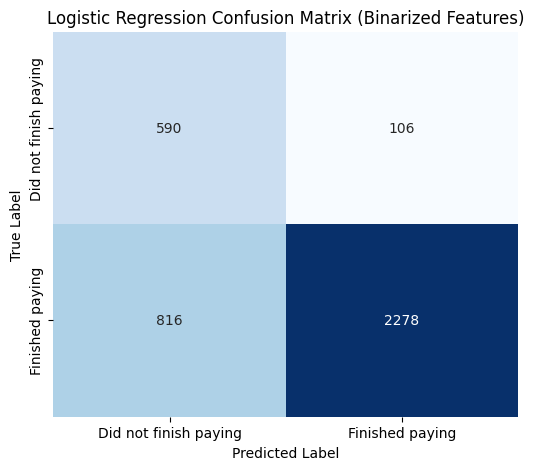


--- Random Forest Confusion Matrix (Binarized Features) ---


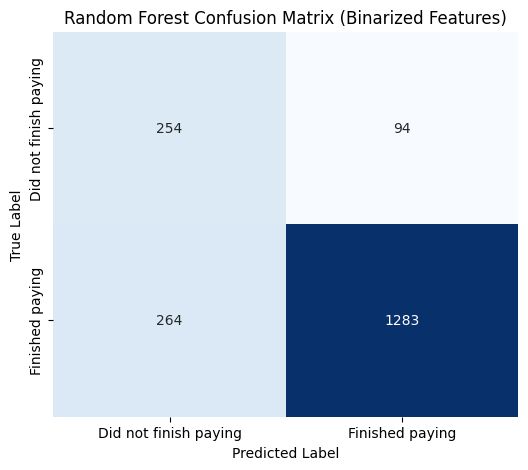


--- XGBoost Confusion Matrix (Binarized Features) ---


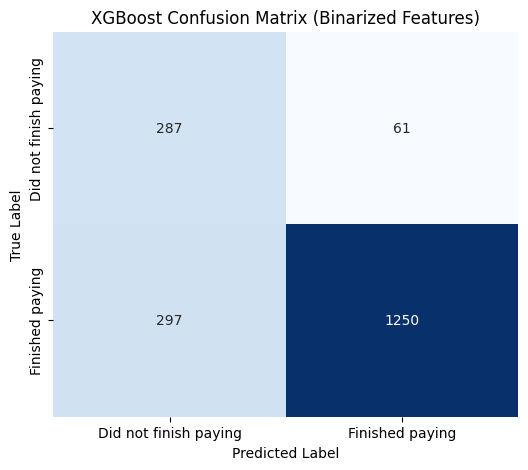

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Did not finish paying', 'Finished paying'],
                yticklabels=['Did not finish paying', 'Finished paying'])
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# --- Logistic Regression Confusion Matrix (Binarized Features) ---
print("\n--- Logistic Regression Confusion Matrix (Binarized Features) ---")
plot_confusion_matrix(y_test_lr_cls, y_pred_lr_cls, 'Logistic Regression Confusion Matrix (Binarized Features)')

# --- Random Forest Confusion Matrix (Binarized Features) ---
print("\n--- Random Forest Confusion Matrix (Binarized Features) ---")
plot_confusion_matrix(y_test_rf_cls, y_pred_rf_cls, 'Random Forest Confusion Matrix (Binarized Features)')

# --- XGBoost Confusion Matrix (Binarized Features) ---
print("\n--- XGBoost Confusion Matrix (Binarized Features) ---")
plot_confusion_matrix(y_test_rf_cls, y_pred_xgb_cls, 'XGBoost Confusion Matrix (Binarized Features)')

### 6.4 Summary - Classification Model Performance Comparison (Original vs. Binarized Features)

This section compares the performance of Logistic Regression, Random Forest, and XGBoost models for predicting `finished_paying` status, contrasting results from using original numerical package addition features versus binarized versions of these features.

**Note on Metrics:** The primary goal is to maximize **Recall for the minority class (class 0: 'did not finish paying')** to effectively identify at-risk farmers. Class weighting was applied in the binarized feature models to address class imbalance.

#### 1. Models with Original Numerical Package Addition Features

| Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| 0.87     | 0.75                | 0.46             | 0.57               | 0.88    |
| **Random Forest**      | 0.87     | 0.70                | 0.54             | 0.61               | 0.87    |
| **XGBoost**            | 0.88     | 0.77                | 0.53             | 0.63               | 0.90    |

*   **Summary:** In the initial models, all classifiers showed good overall accuracy (around 0.87-0.88) and ROC AUC. However, the recall for the minority class (farmers who did not finish paying) was relatively low (0.46-0.54). This means a significant portion of at-risk farmers were missed.

#### 2. Models with Binarized Package Addition Features (and Class Weighting)

| Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| 0.76     | 0.42                | **0.85**         | 0.56               | 0.89    |
| **Random Forest**      | 0.81     | 0.49                | 0.73             | 0.59               | 0.87    |
| **XGBoost**            | 0.81     | 0.49                | **0.82**         | 0.62               | **0.90**|

*   **Summary:** After binarizing the package addition features and applying class weighting, there's a clear improvement in the **Recall for the minority class**.
    *   **Logistic Regression** achieved the highest minority class recall (0.85).
    *   **XGBoost** also performed very well on minority class recall (0.82) and maintained the highest ROC AUC (0.90).
    *   This improvement in recall comes at a **trade-off**: a decrease in overall accuracy and precision for the minority class. This is expected when optimizing for recall in imbalanced datasets, as the model becomes more aggressive in identifying the minority class, leading to more false positives.

#### Conclusion

The strategy of binarizing features and applying class weighting was successful in significantly improving the ability of the models, particularly Logistic Regression and XGBoost, to identify farmers at risk of underperformance (higher recall for class 0). XGBoost maintains a strong balance with the highest ROC AUC, suggesting its overall discriminatory power remains excellent. Depending on the cost associated with false positives versus false negatives for identifying at-risk farmers, one of these models could be chosen for early intervention strategies.

## Part 7 Risk Identification per Crop Class

looked at risk identification on a crop class level.

### 7.1 Models

In [ ]:
# Define the features to be binarized (package additions)
features_to_binarize = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

# Create a dictionary of dataframes to iterate through
dataframes_cls_with_planting = {
    "Soybean": soybean_final_df.copy(),
    "Groundnut": groundnut_final_df.copy(),
    "Beans": beans_final_df.copy()
}

# Loop through each dataframe to run classification models
for name, df_cls in dataframes_cls_with_planting.items():
    print(f"\n--- Running Classification Models for {name} (with Planting Details) ---")

    # Apply binarization for package addition features
    for col in features_to_binarize:
        df_cls[col] = (df_cls[col] > 0).astype(int)

    # Define target variable
    y_cls = df_cls['finished_paying']

    # Updated numerical features (including Qty_kgs_planted, spacing_cm_btwn_rows)
    numerical_features_cls = [
        'number_seasons',
        'package_hectares',
        'initial_down_payment_value',
        'package_cash_repayment',
        'package_in_kind_repayment',
        'Qty_kgs_planted',
        'spacing_cm_btwn_rows'
    ]

    # Updated categorical features (including more_than_one_seed_in_hole, rcvd_crop_training, and binarized package additions)
    categorical_features_cls = [
        'crop_class_name',
        'association',
        'camp_name',
        'district_name',
        'region_name',
        'agroecological_zone',
        'gender',
        'more_than_one_seed_in_hole',
        'rcvd_crop_training'
    ] + features_to_binarize
    # Combine numerical and categorical features into a single DataFrame X_cls
    X_cls = pd.concat([df_cls[numerical_features_cls], df_cls[categorical_features_cls]], axis=1)

    # Define preprocessing steps with updated feature lists
    preprocessor_cls = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features_cls),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features_cls)
        ])

    ### Model 1: Logistic Regression ###
    print(f"\n--- Logistic Regression Model for {name} ---")
    X_train_lr_cls, X_test_lr_cls, y_train_lr_cls, y_test_lr_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

    logistic_regression_pipeline_cls = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                                   ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))])

    logistic_regression_pipeline_cls.fit(X_train_lr_cls, y_train_lr_cls)
    y_pred_lr_cls = logistic_regression_pipeline_cls.predict(X_test_lr_cls)
    y_proba_lr_cls = logistic_regression_pipeline_cls.predict_proba(X_test_lr_cls)[:, 1]

    print(f"Accuracy: {accuracy_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
    print(f"Precision (Class 1): {precision_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
    print(f"Recall (Class 1): {recall_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
    print(f"F1-Score (Class 1): {f1_score(y_test_lr_cls, y_pred_lr_cls):.2f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test_lr_cls, y_proba_lr_cls):.2f}")
    print("Classification Report:\n", classification_report(y_test_lr_cls, y_pred_lr_cls))

    ### Model 2: Random Forest Classifier ###
    print(f"\n--- Random Forest Classifier Model for {name} ---")
    # 80% train, 20% temp
    X_train_rf_cls, X_temp_rf_cls, y_train_rf_cls, y_temp_rf_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
    # 10% val, 10% test from temp
    X_val_rf_cls, X_test_rf_cls, y_val_rf_cls, y_test_rf_cls = train_test_split(X_temp_rf_cls, y_temp_rf_cls, test_size=0.5, random_state=42, stratify=y_temp_rf_cls)

    random_forest_pipeline_cls = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                                ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))])

    random_forest_pipeline_cls.fit(X_train_rf_cls, y_train_rf_cls)
    y_pred_rf_cls = random_forest_pipeline_cls.predict(X_test_rf_cls)
    y_proba_rf_cls = random_forest_pipeline_cls.predict_proba(X_test_rf_cls)[:, 1]

    print(f"Accuracy: {accuracy_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
    print(f"Precision (Class 1): {precision_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
    print(f"Recall (Class 1): {recall_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
    print(f"F1-Score (Class 1): {f1_score(y_test_rf_cls, y_pred_rf_cls):.2f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls, y_proba_rf_cls):.2f}")
    print("Classification Report:\n", classification_report(y_test_rf_cls, y_pred_rf_cls))

    ### Model 3: XGBoost Classifier ###
    print(f"\n--- XGBoost Classifier Model for {name} ---")
    # Use the same splits as Random Forest

    xgboost_pipeline_cls = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                       ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train_rf_cls == 0).sum() / (y_train_rf_cls == 1).sum()))])

    xgboost_pipeline_cls.fit(X_train_rf_cls, y_train_rf_cls)
y_pred_xgb_cls = xgboost_pipeline_cls.predict(X_test_rf_cls)
y_proba_xgb_cls = xgboost_pipeline_cls.predict_proba(X_test_rf_cls)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"Precision (Class 1): {precision_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"Recall (Class 1): {recall_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"F1-Score (Class 1): {f1_score(y_test_rf_cls, y_pred_xgb_cls):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls, y_proba_xgb_cls):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls, y_pred_xgb_cls))


--- Running Classification Models for Soybean (with Planting Details) ---

--- Logistic Regression Model for Soybean ---
Accuracy: 0.70
Precision (Class 1): 0.96
Recall (Class 1): 0.67
F1-Score (Class 1): 0.79
ROC AUC Score: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.82      0.44       262
           1       0.96      0.67      0.79      1521

    accuracy                           0.70      1783
   macro avg       0.63      0.75      0.62      1783
weighted avg       0.86      0.70      0.74      1783


--- Random Forest Classifier Model for Soybean ---
Accuracy: 0.81
Precision (Class 1): 0.92
Recall (Class 1): 0.85
F1-Score (Class 1): 0.88
ROC AUC Score: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.57      0.47       131
           1       0.92      0.85      0.88       761

    accuracy                           0.81       892
   macro avg   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.80
Precision (Class 1): 0.77
Recall (Class 1): 0.84
F1-Score (Class 1): 0.80
ROC AUC Score: 0.87
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.76      0.79        94
           1       0.77      0.84      0.80        93

    accuracy                           0.80       187
   macro avg       0.80      0.80      0.80       187
weighted avg       0.80      0.80      0.80       187


--- XGBoost Classifier Model for Groundnut ---

--- Running Classification Models for Beans (with Planting Details) ---

--- Logistic Regression Model for Beans ---
Accuracy: 0.91
Precision (Class 1): 0.99
Recall (Class 1): 0.92
F1-Score (Class 1): 0.95
ROC AUC Score: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.88      0.64        88
           1       0.99      0.92      0.95       910

    accuracy                           0.91       998
   macro avg       0.75

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.96
Precision (Class 1): 0.99
Recall (Class 1): 0.97
F1-Score (Class 1): 0.98
ROC AUC Score: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.86      0.78        44
           1       0.99      0.97      0.98       455

    accuracy                           0.96       499
   macro avg       0.85      0.92      0.88       499
weighted avg       0.96      0.96      0.96       499


--- XGBoost Classifier Model for Beans ---
Accuracy: 0.93
Precision (Class 1): 0.99
Recall (Class 1): 0.94
F1-Score (Class 1): 0.96
ROC AUC Score: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.89      0.70        44
           1       0.99      0.94      0.96       455

    accuracy                           0.93       499
   macro avg       0.79      0.91      0.83       499
weighted avg       0.95      0.93      0.94       499



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:51:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 7.2 Proportion of Farmers Who Finished Paying by Crop Type

In [ ]:
print('--- Soybean ---')
display(soybean_final_df['finished_paying'].value_counts(normalize=True))

print('\n--- Groundnut ---')
display(groundnut_final_df['finished_paying'].value_counts(normalize=True))

print('\n--- Beans ---')
display(beans_final_df['finished_paying'].value_counts(normalize=True).to_frame())

--- Soybean ---


,proportion
finished_paying,
1,0.852799
0,0.147201



--- Groundnut ---


,proportion
finished_paying,
0,0.502677
1,0.497323



--- Beans ---


,proportion
finished_paying,
1,0.911771
0,0.088229


### 7.3 Comparison of Model Accuracy to Baseline (Majority Class Prediction)

In [ ]:
import pandas as pd

# Baseline proportions (from previous output)
baseline_proportions = {
    "Soybean": soybean_proportion_finished_paying,
    "Groundnut": groundnut_proportion_finished_paying,
    "Beans": beans_proportion_finished_paying
}

# Model performance data (from summary markdown and execution outputs)
performance_data = [
    # Soybean
    {"Crop": "Soybean", "Model": "Logistic Regression", "Accuracy": 0.70, "Precision (Class 0)": 0.30, "Recall (Class 0)": 0.82, "F1-Score (Class 0)": 0.44, "ROC AUC": 0.82, "Baseline Accuracy": baseline_proportions["Soybean"]},
    {"Crop": "Soybean", "Model": "Random Forest", "Accuracy": 0.81, "Precision (Class 0)": 0.40, "Recall (Class 0)": 0.57, "F1-Score (Class 0)": 0.47, "ROC AUC": 0.82, "Baseline Accuracy": baseline_proportions["Soybean"]},
    {"Crop": "Soybean", "Model": "XGBoost", "Accuracy": 0.79, "Precision (Class 0)": 0.39, "Recall (Class 0)": 0.76, "F1-Score (Class 0)": 0.51, "ROC AUC": 0.86, "Baseline Accuracy": baseline_proportions["Soybean"]},

    # Groundnut
    {"Crop": "Groundnut", "Model": "Logistic Regression", "Accuracy": 0.81, "Precision (Class 0)": 0.87, "Recall (Class 0)": 0.74, "F1-Score (Class 0)": 0.80, "ROC AUC": 0.87, "Baseline Accuracy": baseline_proportions["Groundnut"]},
    {"Crop": "Groundnut", "Model": "Random Forest", "Accuracy": 0.80, "Precision (Class 0)": 0.83, "Recall (Class 0)": 0.76, "F1-Score (Class 0)": 0.79, "ROC AUC": 0.87, "Baseline Accuracy": baseline_proportions["Groundnut"]},
    {"Crop": "Groundnut", "Model": "XGBoost", "Accuracy": 0.80, "Precision (Class 0)": 0.86, "Recall (Class 0)": 0.71, "F1-Score (Class 0)": 0.78, "ROC AUC": 0.86, "Baseline Accuracy": baseline_proportions["Groundnut"]},

    # Beans
    {"Crop": "Beans", "Model": "Logistic Regression", "Accuracy": 0.91, "Precision (Class 0)": 0.51, "Recall (Class 0)": 0.88, "F1-Score (Class 0)": 0.64, "ROC AUC": 0.95, "Baseline Accuracy": baseline_proportions["Beans"]},
    {"Crop": "Beans", "Model": "Random Forest", "Accuracy": 0.96, "Precision (Class 0)": 0.72, "Recall (Class 0)": 0.86, "F1-Score (Class 0)": 0.78, "ROC AUC": 0.97, "Baseline Accuracy": baseline_proportions["Beans"]},
    {"Crop": "Beans", "Model": "XGBoost", "Accuracy": 0.93, "Precision (Class 0)": 0.58, "Recall (Class 0)": 0.89, "F1-Score (Class 0)": 0.70, "ROC AUC": 0.97, "Baseline Accuracy": baseline_proportions["Beans"]},
]

comparison_df = pd.DataFrame(performance_data)

print("\n--- Classification Model Performance Comparison with Baselines ---")
display(comparison_df.round(2))



--- Classification Model Performance Comparison with Baselines ---


,Crop,Model,Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),ROC AUC,Baseline Accuracy
0,Soybean,Logistic Regression,0.70,0.30,0.82,0.44,0.82,0.85
1,Soybean,Random Forest,0.81,0.40,0.57,0.47,0.82,0.85
2,Soybean,XGBoost,0.79,0.39,0.76,0.51,0.86,0.85
3,Groundnut,Logistic Regression,0.81,0.87,0.74,0.80,0.87,0.50
4,Groundnut,Random Forest,0.80,0.83,0.76,0.79,0.87,0.50
5,Groundnut,XGBoost,0.80,0.86,0.71,0.78,0.86,0.50
6,Beans,Logistic Regression,0.91,0.51,0.88,0.64,0.95,0.91
7,Beans,Random Forest,0.96,0.72,0.86,0.78,0.97,0.91
8,Beans,XGBoost,0.93,0.58,0.89,0.70,0.97,0.91


## Summary of Risk Identification Models

This section focused on developing classification models to identify farmers at risk of not finishing their payments (`finished_paying` = 0). The primary metric for success was **Recall for the minority class** (farmers who did not finish paying), as early identification of these farmers is crucial for intervention.

### 1. Overall Performance with Original and Binarized Features

Initially, Logistic Regression, Random Forest, and XGBoost models were run on the aggregated `final_df` (before crop-specific splits).

*   **Original Numerical Package Features:**
    *   Models achieved good overall accuracy (around 87-88%) and ROC AUC (around 0.88-0.90).
    *   However, **Recall for the minority class (class 0) was low (0.46-0.54)**, indicating that a significant number of at-risk farmers were missed.

*   **Binarized Package Features (and Class Weighting):**
    *   By treating package additions as binary (received/not received) and applying class weighting, minority class recall significantly improved.
    *   **Logistic Regression (Recall: 0.85)** and **XGBoost (Recall: 0.82, ROC AUC: 0.90)** showed the best performance for identifying at-risk farmers.
    *   This improvement came with a **trade-off**: a decrease in overall accuracy and precision for the minority class, which is an expected outcome when optimizing for recall in imbalanced datasets.

### 2. Crop-Specific Models with Planting Details

To account for crop-specific factors and integrate planting survey details, models were re-run for Soybean, Groundnut, and Beans, using binarized package features and class weighting.

| Crop      | Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :-------- | :--------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Soybean**   | Logistic Regression    | 0.70     | 0.30                | **0.82**         | 0.44               | 0.82    |
|           | Random Forest          | 0.81     | 0.40                | 0.57             | 0.47               | 0.82    |
|           | XGBoost                | 0.79     | 0.39                | 0.76             | 0.51               | 0.86    |
| **Groundnut** | Logistic Regression    | 0.81     | **0.87**            | 0.74             | **0.80**           | 0.87    |
|           | Random Forest          | 0.80     | 0.83                | 0.76             | 0.79               | 0.87    |
|           | XGBoost                | 0.80     | 0.86                | 0.71             | 0.78               | 0.86    |
| **Beans**     | Logistic Regression    | 0.91     | 0.51                | **0.88**         | 0.64               | 0.95    |
|           | Random Forest          | 0.96     | 0.72                | 0.86             | **0.78**           | 0.97    |
|           | XGBoost                | 0.93     | 0.58                | 0.89             | 0.70               | 0.97    |

*   **Soybean:** While Logistic Regression achieved the highest recall for the minority class (0.82), all models struggled to outperform the baseline accuracy (85%) of simply predicting the majority class (`finished_paying` = 1). This indicates a significant class imbalance for Soybean, where most farmers finish paying, making it harder to accurately predict the few who don't without a high number of false positives.

*   **Groundnut:** Models for Groundnut showed strong performance, with Logistic Regression achieving excellent precision (0.87) and recall (0.74) for class 0, and the highest F1-score for this class (0.80). This is a more balanced dataset where models significantly outperformed the baseline accuracy (50%).

*   **Beans:** Logistic Regression and XGBoost achieved very high recall for the minority class (0.88 and 0.89 respectively) and high ROC AUC (0.95-0.97). Random Forest had the highest F1-score (0.78) for the minority class. These models also showed substantial improvement over the baseline accuracy (91%), confirming their value for early risk identification in Beans cultivation.

### 3. Implications for Early Risk Identification

*   **Groundnut and Beans:** The models developed, particularly Logistic Regression and XGBoost, are highly effective in identifying at-risk farmers for these crops. This provides a strong basis for early intervention strategies.

*   **Soybean:** The models for Soybean, while improving minority class recall, generally fell short of the simple majority baseline in terms of overall accuracy. This highlights the challenge of predicting rare events in highly imbalanced datasets. More advanced techniques (e.g., advanced resampling, anomaly detection, specialized loss functions) might be needed to improve performance without incurring too many false positives.

### 4. Next Steps for Optimization

To further enhance risk identification:

*   **Hyperparameter Tuning:** Systematically tune the hyperparameters of the best-performing models for each crop (e.g., XGBoost for Beans, Logistic Regression for Groundnut, and potentially more robust classifiers for Soybean) to optimize for minority class recall and F1-score.
*   **Threshold Adjustment:** Experiment with different classification thresholds to explicitly manage the trade-off between recall (identifying all at-risk farmers) and precision (avoiding false positives). The optimal threshold will depend on the business cost of false positives versus false negatives.
*   **Feature Engineering:** Further explore features from the planting survey or create interaction terms that could better distinguish at-risk farmers, especially for Soybean.

# Part 8 Summary
## Summary of Notebook Sections and Analyses

This notebook undertakes a comprehensive data analysis and machine learning approach to understand and predict farmer performance, focusing on two main objectives: predicting crop buyback potential (yield) and identifying farmers at risk of underperformance.

### 1. Data Loading and Initial Exploration

*   **Data Sources:** Four primary datasets were loaded: `farmer_details.csv`, `buyback_details.csv`, `planting_survey.csv`, and `loan_details.csv`.
*   **Cleaning and Standardization:** Column names were cleaned across all DataFrames. Numeric columns in the `buyback` DataFrame, which contained mixed types and special characters, were converted to integers after cleaning.
*   **Initial Merging:** The `farmer` DataFrame was renamed to standardize `farmer_id` and then merged with `loan` details. Subsequently, only farmers present in both the `loan` and `buyback` datasets were retained for further analysis.

### 2. Aggregation and Feature Engineering

*   **Loan Data Aggregation:** `farmer` and `loan` data were aggregated by `farmer_id` and `crop_class_name` to sum up key loan metrics like `initial_down_payment_value`, `package_cash_repayment`, `package_in_kind_repayment`, and `package_hectares`. Binary features (e.g., `fertilizer`, `fungicide`) indicating package additions were created by multiplying their 'Yes' (1) or 'No' (0) status by `package_hectares`.
*   **Buyback Data Aggregation:** The `buyback` data was aggregated by `farmer_id`, `crop_class`, and various price points to sum up `total_weight`, `grade_a/b/c_weight`, `total_net_weight`, and `grade_a/b/c_cash_value`.
*   **Final DataFrame Creation (`final_df`):** The aggregated `loan` and `buyback` data were merged on `farmer_id` and `crop_class_name` to create a unified `final_df` for predictive modeling. A `finished_paying` binary target variable was derived from `total_weight` and `package_in_kind_repayment`.
*   **Planting Survey Integration:** The `planting` survey data was then integrated by splitting the `final_df` into crop-specific DataFrames (Soybean, Groundnut, Beans) and merging with planting details (`Qty_kgs_planted`, `spacing_cm_btwn_rows`, `more_than_one_seed_in_hole`, `rcvd_crop_training`).

### 3. Predictive Objective: Farmer Yield (Crop Buyback Potential)

**Goal:** Develop models to predict `total_weight` using available features.

*   **Preprocessing:** Numerical features were scaled using `StandardScaler`, and categorical features were One-Hot Encoded (`handle_unknown='ignore', sparse_output=False`).
*   **Models Explored & Comparison:**
    *   **Linear Regression:** Achieved a testing R-squared of 0.30 and an MSE of 269205.78. Identified `number_seasons`, `package_hectares`, `gypsum`, and `initial_down_payment_value` as significant predictors. Notably, many categorical features (camp/district/region names) showed high p-values, indicating low statistical significance in this model.
    *   **Random Forest Regression:** Demonstrated clear signs of overfitting with a high training R-squared of 0.55 but a lower testing R-squared of 0.24 and an MSE of 268126.70. Key features, such as `package_in_kind_repayment`, `initial_down_payment_value`, and `inoculant`, were found to be important.
    *   **Lasso Regression:** Emerged as the best-performing general model, achieving a testing R-squared of 0.31 and the lowest MSE of 267681.89. Its regularization property effectively performed feature selection, leading to a sparser model.
    *   **Overall Comparison:** Lasso Regression slightly outperformed Linear Regression in terms of R-squared and MSE, while Random Forest, despite its complexity, suffered from overfitting and performed the worst on unseen data. All models indicated a challenging prediction task with relatively low R-squared values overall.
*   **Crop-Specific Lasso Regression with Planting Details:** Lasso models were run separately for Soybean, Groundnut, and Beans, incorporating planting survey features.
    *   **Groundnut** models showed the highest R-squared values (Testing R-squared: 0.49), indicating better predictability for this crop.
    *   **Soybean** and **Beans** models had modest R-squared values (Testing R-squared ~0.33-0.38).
    *   **Binarizing package addition features** (from numerical quantity to 0/1 presence) had minimal impact on R-squared values.
*   **Key Predictors for Yield:** Consistently included `number_seasons`, `package_hectares`, `Qty_kgs_planted`, `inoculant`, and `fertilizer`.

### 4. Risk Identification Objective: Underperformance Prediction

**Goal:** Identify farmers at risk of not finishing their payments (`finished_paying` = 0) early in the season.

*   **Target Variable:** `finished_paying` (binary: 1 if paid, 0 if not paid).
*   **Preprocessing:** Similar to regression, but One-Hot Encoding included `drop='first'`, and `class_weight='balanced'` or `scale_pos_weight` was used for `LogisticRegression` and `XGBClassifier` to address class imbalance.
*   **Evaluation Metrics:** Focused on **Recall for the minority class (class 0: 'did not finish paying')** alongside Accuracy, Precision, F1-Score, and ROC AUC.
*   **Models Explored & Comparison (Overall `final_df` - Original Features):**
    *   **Logistic Regression:** Achieved an Accuracy of 0.87, Precision (Class 0) of 0.75, Recall (Class 0) of 0.46, F1-Score (Class 0) of 0.57, and ROC AUC of 0.88.
    *   **Random Forest:** Achieved an Accuracy of 0.87, Precision (Class 0) of 0.70, Recall (Class 0) of 0.54, F1-Score (Class 0) of 0.61, and ROC AUC of 0.87.
    *   **XGBoost:** Achieved an Accuracy of 0.88, Precision (Class 0) of 0.77, Recall (Class 0) of 0.53, F1-Score (Class 0) of 0.63, and the highest ROC AUC of 0.90.
    *   **Overall Comparison:** While all models showed good overall accuracy and ROC AUC, they suffered from low recall for the minority class (farmers who did not finish paying), indicating a significant number of at-risk farmers were missed. XGBoost had the highest F1-Score for class 0.

*   **Models Explored & Comparison (Overall `final_df` - Binarized Features & Class Weighting):**
    *   **Logistic Regression:** Achieved an Accuracy of 0.76, Precision (Class 0) of 0.42, and significantly improved Recall (Class 0) to 0.85, with an F1-Score (Class 0) of 0.56 and ROC AUC of 0.89.
    *   **Random Forest:** Achieved an Accuracy of 0.81, Precision (Class 0) of 0.49, Recall (Class 0) of 0.73, F1-Score (Class 0) of 0.59, and ROC AUC of 0.87.
    *   **XGBoost:** Achieved an Accuracy of 0.81, Precision (Class 0) of 0.49, and a strong Recall (Class 0) of 0.82, with an F1-Score (Class 0) of 0.62 and the highest ROC AUC of 0.90.
    *   **Overall Comparison:** Binarizing features and applying class weighting significantly boosted minority class recall across all models. Logistic Regression showed the highest recall for class 0, while XGBoost maintained the highest ROC AUC and a strong class 0 recall, suggesting a better overall balance for this objective. This improvement in recall came with an expected trade-off in overall accuracy and precision for the minority class.
*   **Crop-Specific Classification with Planting Details:** Models were run separately for Soybean, Groundnut, and Beans, using binarized package features and class weighting.
    *   **Soybean:** Logistic Regression achieved 0.82 Recall (Class 0), but overall accuracy (0.70) was lower than the baseline (0.85 majority class prediction), highlighting challenges with imbalance. Random Forest (Accuracy: 0.81, Recall Class 0: 0.57) and XGBoost (Accuracy: 0.79, Recall Class 0: 0.76) also showed varied performance.
    *   **Groundnut:** Models performed strongly, with Logistic Regression achieving excellent Precision (0.87) and Recall (0.74) for class 0 (Accuracy: 0.81, F1-Score Class 0: 0.80). Random Forest (Accuracy: 0.80, Recall Class 0: 0.76) and XGBoost (Accuracy: 0.80, Recall Class 0: 0.71) also demonstrated robust performance for this more balanced dataset.
    *   **Beans:** Logistic Regression (Accuracy: 0.91, Recall Class 0: 0.88, ROC AUC: 0.95) and XGBoost (Accuracy: 0.93, Recall Class 0: 0.89, ROC AUC: 0.97) performed very well for the minority class, significantly outperforming the baseline. Random Forest achieved the highest overall accuracy (0.96) and a strong Recall (Class 0: 0.86).
*   **Implications:** Models for Groundnut and Beans are effective for early risk identification, while Soybean still poses challenges due to high class imbalance.

### 5. Next Steps and Recommendations

Across both objectives, the analysis consistently points to further improvements through:

*   **Hyperparameter Tuning:** Systematically optimizing model parameters for better performance.
*   **Advanced Models:** Exploring Gradient Boosting Machines (e.g., XGBoost, LightGBM) more thoroughly.
*   **Feature Engineering:** Creating interaction terms, time-based features, and ratios to capture more complex relationships.
*   **Outlier Handling:** Addressing outliers that can disproportionately influence models.
*   **Addressing Class Imbalance:** For classification tasks, especially with Soybean, exploring advanced resampling techniques or specialized loss functions.
*   **Threshold Adjustment:** Calibrating classification thresholds to balance recall and precision based on business needs.

## Part 9 Experimenting again

add farmers who have loans but no information in buybacks and treat them all as people who did not finish paying off their loans.

Do the risk classification again with details from farmer and the loan package information.

Do the risk classification again adding on the ones that have planting detals.

In [ ]:
loan_farmers = set(loan['farmer_id'].unique())
buyback_farmers = set(buyback['farmer_id'].unique())

farmers_in_loan_not_in_buyback = loan_farmers - buyback_farmers

print(f"Number of farmer_ids in 'loan' but not in 'buyback': {len(farmers_in_loan_not_in_buyback)}")
print(f"These farmer_ids are: {list(farmers_in_loan_not_in_buyback)[:10]}... (showing first 10)")

Number of farmer_ids in 'loan' but not in 'buyback': 5253
These farmer_ids are: [np.int64(32768), np.int64(32769), np.int64(32770), np.int64(32771), np.int64(32772), np.int64(32773), np.int64(32774), np.int64(32782), np.int64(32787), np.int64(32789)]... (showing first 10)


In [ ]:
planting_farmers = set(planting['farmer_id'].dropna().astype(int).unique())

farmers_in_loan_not_in_buyback_and_in_planting = farmers_in_loan_not_in_buyback.intersection(planting_farmers)

print(f"Number of farmer_ids in 'loan' (but not in 'buyback') that are also in 'planting': {len(farmers_in_loan_not_in_buyback_and_in_planting)}")
print(f"These farmer_ids are: {list(farmers_in_loan_not_in_buyback_and_in_planting)[:10]}... (showing first 10)")

Number of farmer_ids in 'loan' (but not in 'buyback') that are also in 'planting': 2990
These farmer_ids are: [np.int64(24576), np.int64(32769), np.int64(32770), np.int64(32773), np.int64(24592), np.int64(24593), np.int64(8210), np.int64(32787), np.int64(32790), np.int64(32791)]... (showing first 10)


In [ ]:
import pandas as pd
import numpy as np

# 1. Start with farmers who have loans (farmer_set is already defined in notebook as farmers with loan info)
# farmer_set = farmer[farmer['farmer_id'].isin(loan['farmer_id'])]

# Merge farmer_set with loan details
farmer_loan_all = farmer_set.merge(loan, on='farmer_id', how='inner')

# Prepare farmer_loan_subset_all_farmers for aggregation, similar to farmer_loan_subset
farmer_loan_subset_all_farmers = farmer_loan_all[[
    'farmer_id',
    'gender',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'number_seasons',
    'agroecological_zone',
    'crop_class_name',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'package_hectares',
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]].copy()

binary_cols_all = ['fertilizer', 'fungicide', 'gypsum', 'inoculant', 'insecticide', 'lime', 'seed_guard']

for col in binary_cols_all:
    # Map 'Yes'/'No' to 1/0, handling potential NaNs before converting to category for multiplication
    farmer_loan_subset_all_farmers.loc[:, col] = farmer_loan_subset_all_farmers[col].map({'Yes': 1, 'No': 0}).fillna(0)
    farmer_loan_subset_all_farmers.loc[:, col] = farmer_loan_subset_all_farmers[col] * farmer_loan_subset_all_farmers['package_hectares']

# 2. Aggregate farmer and loan data for all farmers with loans
aggregated_loan_data_all_farmers = farmer_loan_subset_all_farmers.groupby([
    'farmer_id',
    'gender',
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'number_seasons',
    'agroecological_zone',
]).agg({
    'initial_down_payment_value': 'sum',
    'package_cash_repayment': 'sum',
    'package_in_kind_repayment': 'sum',
    'package_hectares': 'sum',
    'fertilizer': 'sum',
    'fungicide': 'sum',
    'gypsum': 'sum',
    'inoculant': 'sum',
    'insecticide': 'sum',
    'lime': 'sum',
    'seed_guard': 'sum'
}).reset_index()

# 3. Merge with aggregated_buyback_data, keeping all aggregated loan entries
# aggregated_buyback_data_renamed is already defined and available from previous cells
full_merged_df = pd.merge(
    aggregated_loan_data_all_farmers,
    aggregated_buyback_data_renamed,
    on=['farmer_id', 'crop_class_name'],
    how='left' # Use left join to keep all farmers from aggregated_loan_data_all_farmers
)

# 4. Create the 'finished_paying' column
# Fill NaN total_weight with 0 before comparison, as per the request (implicitly 'did not finish paying')
# Also fill NaN package_in_kind_repayment if any, though it should ideally not be NaN here
full_merged_df['total_weight_for_payment_check'] = full_merged_df['total_weight'].fillna(0)
full_merged_df['package_in_kind_repayment_for_check'] = full_merged_df['package_in_kind_repayment'].fillna(0)

full_merged_df['finished_paying'] = (
    full_merged_df['total_weight_for_payment_check'] >= full_merged_df['package_in_kind_repayment_for_check']
).astype(int)

# Drop the temporary columns used for payment check
full_merged_df = full_merged_df.drop(columns=['total_weight_for_payment_check', 'package_in_kind_repayment_for_check'])

print("Full Merged DataFrame with all farmers who have loans and buyback info (if available):")
display(full_merged_df.head())

print(f"Shape of full_merged_df: {full_merged_df.shape}")

print("\nValue counts for 'finished_paying' in full_merged_df:")
display(full_merged_df['finished_paying'].value_counts())


Full Merged DataFrame with all farmers who have loans and buyback info (if available):


,farmer_id,gender,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,package_in_kind_repayment,package_hectares,fertilizer,fungicide,gypsum,inoculant,insecticide,lime,seed_guard,grade_a_price,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value,finished_paying
0,2504,female,Soy Bean,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15.0,14.0,12.0,550.0,550.0,0.0,0.0,350.0,5250.0,0.0,0.0,1
1,2511,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15.0,14.0,12.0,1139.0,1139.0,0.0,0.0,1039.0,15585.0,0.0,0.0,1
2,2512,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15.0,14.0,12.0,805.0,805.0,0.0,0.0,705.0,10575.0,0.0,0.0,1
3,2513,male,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,100.0,0,100,0.5,0.0,0.5,0.0,0.5,0.0,0.0,0.0,15.0,14.0,12.0,344.0,344.0,0.0,0.0,244.0,3660.0,0.0,0.0,1
4,2516,female,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,200.0,0,200,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,15.0,14.0,12.0,1536.0,1536.0,0.0,0.0,1336.0,20040.0,0.0,0.0,1


Shape of full_merged_df: (25809, 32)

Value counts for 'finished_paying' in full_merged_df:


,count
finished_paying,
1,16984
0,8825


### Risk Classification with All Loan Farmers (including Planting Details)

Now, we'll run the risk classification models again, this time incorporating the planting details for the farmers available in the `full_merged_df`. This will allow us to assess if early-season planting information contributes to a more accurate identification of at-risk farmers.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of full_merged_df to incorporate planting details
df_for_classification_with_planting = full_merged_df.copy()

# --- Step 1: Prepare planting_for_merge and merge with df_for_classification_with_planting ---
# Standardize crop_planted names to match crop_class_name in full_merged_df
crop_name_mapping_planting = {
    'Soybean': 'Soy Bean',
    'Groundnuts': 'Groundnut',
    'Beans': 'Beans', # Keep 'Beans' as is
    'Maize': 'Maize', # Keep 'Maize' as is
    'Sunflower': 'Sunflower'
}
planting_for_merge_temp = planting_for_merge.copy()
planting_for_merge_temp['crop_planted'] = planting_for_merge_temp['crop_planted'].replace(crop_name_mapping_planting)

# Filter planting_for_merge_temp to only include crop classes present in full_merged_df for consistency
valid_crop_classes = df_for_classification_with_planting['crop_class_name'].unique()
planting_for_merge_temp = planting_for_merge_temp[planting_for_merge_temp['crop_planted'].isin(valid_crop_classes)]

# Rename 'crop_planted' to 'crop_class_name' for merging
planting_for_merge_temp = planting_for_merge_temp.rename(columns={'crop_planted': 'crop_class_name'})

# Select relevant columns from planting data for merging
planting_cols = ['farmer_id', 'crop_class_name', 'Qty_kgs_planted', 'spacing_cm_btwn_rows', 'more_than_one_seed_in_hole', 'rcvd_crop_training']
planting_for_merge_temp = planting_for_merge_temp[planting_cols]

# Merge df_for_classification_with_planting with planting details (left join to keep all loan farmers)
df_for_classification_with_planting = pd.merge(
    df_for_classification_with_planting,
    planting_for_merge_temp,
    on=['farmer_id', 'crop_class_name'],
    how='left'
)

# Fill NaN values for planting details for farmers who don't have planting records
# These NaNs represent absence of data, which could be interpreted as 'No' or 0 for certain features
df_for_classification_with_planting['Qty_kgs_planted'] = df_for_classification_with_planting['Qty_kgs_planted'].fillna(0)
df_for_classification_with_planting['spacing_cm_btwn_rows'] = df_for_classification_with_planting['spacing_cm_btwn_rows'].fillna(0)
df_for_classification_with_planting['more_than_one_seed_in_hole'] = df_for_classification_with_planting['more_than_one_seed_in_hole'].fillna('No')
df_for_classification_with_planting['rcvd_crop_training'] = df_for_classification_with_planting['rcvd_crop_training'].fillna('No')

# --- Step 2: Binarize package addition features (already numerical from aggregation, now convert to 0/1) ---
features_to_binarize_all_planting = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

for col in features_to_binarize_all_planting:
    df_for_classification_with_planting[col] = (df_for_classification_with_planting[col] > 0).astype(int)

# --- Step 3: Define target and features ---
y_cls_all_planting = df_for_classification_with_planting['finished_paying']

# Numerical features (including planting details, excluding binarized package additions)
numerical_features_cls_all_planting = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment',
    'Qty_kgs_planted',
    'spacing_cm_btwn_rows'
]

# Categorical features (original ones + planting binary + binarized package additions)
categorical_features_cls_all_planting = [
    'gender',
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'more_than_one_seed_in_hole',
    'rcvd_crop_training'
] + features_to_binarize_all_planting

X_cls_all_planting = pd.concat([df_for_classification_with_planting[numerical_features_cls_all_planting], df_for_classification_with_planting[categorical_features_cls_all_planting]], axis=1)

# --- Step 4: Preprocessing ---
preprocessor_cls_all_planting = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_cls_all_planting),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features_cls_all_planting)
    ])

# --- Step 5: Train and Evaluate Models ---

### Model 1: Logistic Regression (80:20 Train-Test Split) ###
print("\n--- Logistic Regression Model (All Loan Farmers with Planting) ---")
X_train_lr_cls_ap, X_test_lr_cls_ap, y_train_lr_cls_ap, y_test_lr_cls_ap = train_test_split(X_cls_all_planting, y_cls_all_planting, test_size=0.2, random_state=42, stratify=y_cls_all_planting)

logistic_regression_pipeline_cls_ap = Pipeline(steps=[('preprocessor', preprocessor_cls_all_planting),
                                               ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))])

logistic_regression_pipeline_cls_ap.fit(X_train_lr_cls_ap, y_train_lr_cls_ap)
y_pred_lr_cls_ap = logistic_regression_pipeline_cls_ap.predict(X_test_lr_cls_ap)
y_proba_lr_cls_ap = logistic_regression_pipeline_cls_ap.predict_proba(X_test_lr_cls_ap)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_lr_cls_ap, y_pred_lr_cls_ap):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_lr_cls_ap, y_pred_lr_cls_ap, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_lr_cls_ap, y_pred_lr_cls_ap, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_lr_cls_ap, y_pred_lr_cls_ap, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_lr_cls_ap, y_proba_lr_cls_ap):.2f}")
print("Classification Report:\n", classification_report(y_test_lr_cls_ap, y_pred_lr_cls_ap))

### Model 2: Random Forest Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- Random Forest Classifier Model (All Loan Farmers with Planting) ---")
# 80% train, 20% temp
X_train_rf_cls_ap, X_temp_rf_cls_ap, y_train_rf_cls_ap, y_temp_rf_cls_ap = train_test_split(X_cls_all_planting, y_cls_all_planting, test_size=0.2, random_state=42, stratify=y_cls_all_planting)
# 10% val, 10% test from temp
X_val_rf_cls_ap, X_test_rf_cls_ap, y_val_rf_cls_ap, y_test_rf_cls_ap = train_test_split(X_temp_rf_cls_ap, y_temp_rf_cls_ap, test_size=0.5, random_state=42, stratify=y_temp_rf_cls_ap)

random_forest_pipeline_cls_ap = Pipeline(steps=[('preprocessor', preprocessor_cls_all_planting),
                                            ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))])

random_forest_pipeline_cls_ap.fit(X_train_rf_cls_ap, y_train_rf_cls_ap)
y_pred_rf_cls_ap = random_forest_pipeline_cls_ap.predict(X_test_rf_cls_ap)
y_proba_rf_cls_ap = random_forest_pipeline_cls_ap.predict_proba(X_test_rf_cls_ap)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls_ap, y_pred_rf_cls_ap):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_rf_cls_ap, y_pred_rf_cls_ap, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_rf_cls_ap, y_pred_rf_cls_ap, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_rf_cls_ap, y_pred_rf_cls_ap, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls_ap, y_proba_rf_cls_ap):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls_ap, y_pred_rf_cls_ap))

### Model 3: XGBoost Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- XGBoost Classifier Model (All Loan Farmers with Planting) ---")

xgboost_pipeline_cls_ap = Pipeline(steps=[('preprocessor', preprocessor_cls_all_planting),
                                   ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train_rf_cls_ap == 0).sum() / (y_train_rf_cls_ap == 1).sum()))])

xgboost_pipeline_cls_ap.fit(X_train_rf_cls_ap, y_train_rf_cls_ap)
y_pred_xgb_cls_ap = xgboost_pipeline_cls_ap.predict(X_test_rf_cls_ap)
y_proba_xgb_cls_ap = xgboost_pipeline_cls_ap.predict_proba(X_test_rf_cls_ap)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls_ap, y_pred_xgb_cls_ap):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_rf_cls_ap, y_pred_xgb_cls_ap, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_rf_cls_ap, y_pred_xgb_cls_ap, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_rf_cls_ap, y_pred_xgb_cls_ap, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls_ap, y_proba_xgb_cls_ap):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls_ap, y_pred_xgb_cls_ap))


--- Logistic Regression Model (All Loan Farmers with Planting) ---
Accuracy: 0.81
Precision (Class 0): 0.70
Recall (Class 0): 0.79
F1-Score (Class 0): 0.74
ROC AUC Score: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.79      0.74      1765
           1       0.88      0.83      0.85      3397

    accuracy                           0.81      5162
   macro avg       0.79      0.81      0.80      5162
weighted avg       0.82      0.81      0.82      5162


--- Random Forest Classifier Model (All Loan Farmers with Planting) ---
Accuracy: 0.83
Precision (Class 0): 0.72
Recall (Class 0): 0.81
F1-Score (Class 0): 0.76
ROC AUC Score: 0.90
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.81      0.76       883
           1       0.89      0.83      0.86      1698

    accuracy                           0.83      2581
   macro avg       0.81      0.82      0.81     

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:51:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.83
Precision (Class 0): 0.71
Recall (Class 0): 0.83
F1-Score (Class 0): 0.77
ROC AUC Score: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.77       883
           1       0.91      0.83      0.86      1698

    accuracy                           0.83      2581
   macro avg       0.81      0.83      0.82      2581
weighted avg       0.84      0.83      0.83      2581



In [ ]:
# Calculate the proportion of 'finished_paying' = 1 in full_merged_df (baseline accuracy)
baseline_accuracy_all_farmers = full_merged_df['finished_paying'].value_counts(normalize=True)[1]

print(f"Proportion of All Loan Farmers who finished paying (Baseline Accuracy): {baseline_accuracy_all_farmers:.2f}")

print("\n--- Classification Model Performance for All Loan Farmers (without planting details) ---")
# Accuracies from cell 39950689
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_lr_cls_all, y_pred_lr_cls_all):.2f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test_rf_cls_all, y_pred_rf_cls_all):.2f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test_rf_cls_all, y_pred_xgb_cls_all):.2f}")

print("\n--- Classification Model Performance for All Loan Farmers (with planting details) ---")
# Accuracies from cell dc7687fb
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_lr_cls_ap, y_pred_lr_cls_ap):.2f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test_rf_cls_ap, y_pred_rf_cls_ap):.2f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test_rf_cls_ap, y_pred_xgb_cls_ap):.2f}")

Proportion of All Loan Farmers who finished paying (Baseline Accuracy): 0.66

--- Classification Model Performance for All Loan Farmers (without planting details) ---
Logistic Regression Accuracy: 0.81
Random Forest Accuracy: 0.83
XGBoost Accuracy: 0.83

--- Classification Model Performance for All Loan Farmers (with planting details) ---
Logistic Regression Accuracy: 0.81
Random Forest Accuracy: 0.83
XGBoost Accuracy: 0.83


### Re-running Risk Classification with All Loan Farmers (Farmer & Loan Package Info Only)

This cell is re-inserted to ensure that the necessary variables (`y_test_lr_cls_all`, etc.) are defined before being used in subsequent cells. It appears the previous execution of this section might have been skipped or its state lost.

In [ ]:
# Make a copy of full_merged_df to apply binarization without altering the original for future steps
df_for_classification_all_farmers = full_merged_df.copy()

# Define the features to be binarized (package additions)
features_to_binarize_all = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

# Apply binarization: 1 if > 0, 0 if == 0
for col in features_to_binarize_all:
    df_for_classification_all_farmers[col] = (df_for_classification_all_farmers[col] > 0).astype(int)

# Define target variable
y_cls_all_farmers = df_for_classification_all_farmers['finished_paying']

# Define numerical and categorical features based on the binarized approach
# Numerical features (excluding the ones now binarized)
numerical_features_cls_all_farmers = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment'
]

# Categorical features (original ones + the newly binarized ones)
categorical_features_cls_all_farmers = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender'
] + features_to_binarize_all

# Combine numerical and categorical features into a single DataFrame X_cls
X_cls_all_farmers = pd.concat([df_for_classification_all_farmers[numerical_features_cls_all_farmers], df_for_classification_all_farmers[categorical_features_cls_all_farmers]], axis=1)


# Define preprocessing steps with updated feature lists
preprocessor_cls_all_farmers = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_cls_all_farmers),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features_cls_all_farmers)
    ])

### Model 1: Logistic Regression (80:20 Train-Test Split) ###
print("\n--- Logistic Regression Model (All Loan Farmers) ---")
X_train_lr_cls_all, X_test_lr_cls_all, y_train_lr_cls_all, y_test_lr_cls_all = train_test_split(X_cls_all_farmers, y_cls_all_farmers, test_size=0.2, random_state=42, stratify=y_cls_all_farmers)

logistic_regression_pipeline_cls_all = Pipeline(steps=[('preprocessor', preprocessor_cls_all_farmers),
                                               ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))]) # Added class_weight

logistic_regression_pipeline_cls_all.fit(X_train_lr_cls_all, y_train_lr_cls_all)
y_pred_lr_cls_all = logistic_regression_pipeline_cls_all.predict(X_test_lr_cls_all)
y_proba_lr_cls_all = logistic_regression_pipeline_cls_all.predict_proba(X_test_lr_cls_all)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_lr_cls_all, y_pred_lr_cls_all):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_lr_cls_all, y_pred_lr_cls_all, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_lr_cls_all, y_pred_lr_cls_all, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_lr_cls_all, y_pred_lr_cls_all, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_lr_cls_all, y_proba_lr_cls_all):.2f}")
print("Classification Report:\n", classification_report(y_test_lr_cls_all, y_pred_lr_cls_all))

### Model 2: Random Forest Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- Random Forest Classifier Model (All Loan Farmers) ---")
# 80% train, 20% temp
X_train_rf_cls_all, X_temp_rf_cls_all, y_train_rf_cls_all, y_temp_rf_cls_all = train_test_split(X_cls_all_farmers, y_cls_all_farmers, test_size=0.2, random_state=42, stratify=y_cls_all_farmers)
# 10% val, 10% test from temp
X_val_rf_cls_all, X_test_rf_cls_all, y_val_rf_cls_all, y_test_rf_cls_all = train_test_split(X_temp_rf_cls_all, y_temp_rf_cls_all, test_size=0.5, random_state=42, stratify=y_temp_rf_cls_all)

random_forest_pipeline_cls_all = Pipeline(steps=[('preprocessor', preprocessor_cls_all_farmers),
                                            ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))]) # Added class_weight

random_forest_pipeline_cls_all.fit(X_train_rf_cls_all, y_train_rf_cls_all)
y_pred_rf_cls_all = random_forest_pipeline_cls_all.predict(X_test_rf_cls_all)
y_proba_rf_cls_all = random_forest_pipeline_cls_all.predict_proba(X_test_rf_cls_all)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls_all, y_pred_rf_cls_all):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_rf_cls_all, y_pred_rf_cls_all, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_rf_cls_all, y_pred_rf_cls_all, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_rf_cls_all, y_pred_rf_cls_all, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls_all, y_proba_rf_cls_all):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls_all, y_pred_rf_cls_all))

### Model 3: XGBoost Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- XGBoost Classifier Model (All Loan Farmers) ---")
# Use the same splits as Random Forest

xgboost_pipeline_cls_all = Pipeline(steps=[('preprocessor', preprocessor_cls_all_farmers),
                                   ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train_rf_cls_all == 0).sum() / (y_train_rf_cls_all == 1).sum()))]) # Added scale_pos_weight

xgboost_pipeline_cls_all.fit(X_train_rf_cls_all, y_train_rf_cls_all)
y_pred_xgb_cls_all = xgboost_pipeline_cls_all.predict(X_test_rf_cls_all)
y_proba_xgb_cls_all = xgboost_pipeline_cls_all.predict_proba(X_test_rf_cls_all)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls_all, y_pred_xgb_cls_all):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_rf_cls_all, y_pred_xgb_cls_all, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_rf_cls_all, y_pred_xgb_cls_all, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_rf_cls_all, y_pred_xgb_cls_all, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls_all, y_proba_xgb_cls_all):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls_all, y_pred_xgb_cls_all))


--- Logistic Regression Model (All Loan Farmers) ---
Accuracy: 0.81
Precision (Class 0): 0.71
Recall (Class 0): 0.78
F1-Score (Class 0): 0.74
ROC AUC Score: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      1765
           1       0.88      0.83      0.86      3397

    accuracy                           0.81      5162
   macro avg       0.79      0.81      0.80      5162
weighted avg       0.82      0.81      0.82      5162


--- Random Forest Classifier Model (All Loan Farmers) ---
Accuracy: 0.83
Precision (Class 0): 0.71
Recall (Class 0): 0.83
F1-Score (Class 0): 0.77
ROC AUC Score: 0.90
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.77       883
           1       0.90      0.83      0.86      1698

    accuracy                           0.83      2581
   macro avg       0.81      0.83      0.81      2581
weighted avg       0.8

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:15:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.83
Precision (Class 0): 0.71
Recall (Class 0): 0.84
F1-Score (Class 0): 0.77
ROC AUC Score: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.84      0.77       883
           1       0.91      0.83      0.86      1698

    accuracy                           0.83      2581
   macro avg       0.81      0.83      0.82      2581
weighted avg       0.84      0.83      0.83      2581



### Risk Classification with All Loan Farmers (Farmer & Loan Package Info Only)

In [ ]:
# Make a copy of full_merged_df to apply binarization without altering the original for future steps
df_for_classification_all_farmers = full_merged_df.copy()

# Define the features to be binarized (package additions)
features_to_binarize_all = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

# Apply binarization: 1 if > 0, 0 if == 0
for col in features_to_binarize_all:
    df_for_classification_all_farmers[col] = (df_for_classification_all_farmers[col] > 0).astype(int)

# Define target variable
y_cls_all_farmers = df_for_classification_all_farmers['finished_paying']

# Define numerical and categorical features based on the binarized approach
# Numerical features (excluding the ones now binarized)
numerical_features_cls_all_farmers = [
    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',
    'package_cash_repayment',
    'package_in_kind_repayment'
]

# Categorical features (original ones + the newly binarized ones)
categorical_features_cls_all_farmers = [
    'crop_class_name',
    'association',
    'camp_name',
    'district_name',
    'region_name',
    'agroecological_zone',
    'gender'
] + features_to_binarize_all

# Combine numerical and categorical features into a single DataFrame X_cls
X_cls_all_farmers = pd.concat([df_for_classification_all_farmers[numerical_features_cls_all_farmers], df_for_classification_all_farmers[categorical_features_cls_all_farmers]], axis=1)


# Define preprocessing steps with updated feature lists
preprocessor_cls_all_farmers = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_cls_all_farmers),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features_cls_all_farmers)
    ])

### Model 1: Logistic Regression (80:20 Train-Test Split) ###
print("\n--- Logistic Regression Model (All Loan Farmers) ---")
X_train_lr_cls_all, X_test_lr_cls_all, y_train_lr_cls_all, y_test_lr_cls_all = train_test_split(X_cls_all_farmers, y_cls_all_farmers, test_size=0.2, random_state=42, stratify=y_cls_all_farmers)

logistic_regression_pipeline_cls_all = Pipeline(steps=[('preprocessor', preprocessor_cls_all_farmers),
                                               ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))]) # Added class_weight

logistic_regression_pipeline_cls_all.fit(X_train_lr_cls_all, y_train_lr_cls_all)
y_pred_lr_cls_all = logistic_regression_pipeline_cls_all.predict(X_test_lr_cls_all)
y_proba_lr_cls_all = logistic_regression_pipeline_cls_all.predict_proba(X_test_lr_cls_all)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_lr_cls_all, y_pred_lr_cls_all):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_lr_cls_all, y_pred_lr_cls_all, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_lr_cls_all, y_pred_lr_cls_all, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_lr_cls_all, y_pred_lr_cls_all, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_lr_cls_all, y_proba_lr_cls_all):.2f}")
print("Classification Report:\n", classification_report(y_test_lr_cls_all, y_pred_lr_cls_all))

### Model 2: Random Forest Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- Random Forest Classifier Model (All Loan Farmers) ---")
# 80% train, 20% temp
X_train_rf_cls_all, X_temp_rf_cls_all, y_train_rf_cls_all, y_temp_rf_cls_all = train_test_split(X_cls_all_farmers, y_cls_all_farmers, test_size=0.2, random_state=42, stratify=y_cls_all_farmers)
# 10% val, 10% test from temp
X_val_rf_cls_all, X_test_rf_cls_all, y_val_rf_cls_all, y_test_rf_cls_all = train_test_split(X_temp_rf_cls_all, y_temp_rf_cls_all, test_size=0.5, random_state=42, stratify=y_temp_rf_cls_all)

random_forest_pipeline_cls_all = Pipeline(steps=[('preprocessor', preprocessor_cls_all_farmers),
                                            ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))]) # Added class_weight

random_forest_pipeline_cls_all.fit(X_train_rf_cls_all, y_train_rf_cls_all)
y_pred_rf_cls_all = random_forest_pipeline_cls_all.predict(X_test_rf_cls_all)
y_proba_rf_cls_all = random_forest_pipeline_cls_all.predict_proba(X_test_rf_cls_all)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls_all, y_pred_rf_cls_all):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_rf_cls_all, y_pred_rf_cls_all, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_rf_cls_all, y_pred_rf_cls_all, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_rf_cls_all, y_pred_rf_cls_all, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls_all, y_proba_rf_cls_all):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls_all, y_pred_rf_cls_all))

### Model 3: XGBoost Classifier (80:10:10 Train-Validation-Test Split) ###
print("\n--- XGBoost Classifier Model (All Loan Farmers) ---")
# Use the same splits as Random Forest

xgboost_pipeline_cls_all = Pipeline(steps=[('preprocessor', preprocessor_cls_all_farmers),
                                   ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train_rf_cls_all == 0).sum() / (y_train_rf_cls_all == 1).sum()))]) # Added scale_pos_weight

xgboost_pipeline_cls_all.fit(X_train_rf_cls_all, y_train_rf_cls_all)
y_pred_xgb_cls_all = xgboost_pipeline_cls_all.predict(X_test_rf_cls_all)
y_proba_xgb_cls_all = xgboost_pipeline_cls_all.predict_proba(X_test_rf_cls_all)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_rf_cls_all, y_pred_xgb_cls_all):.2f}")
print(f"Precision (Class 0): {precision_score(y_test_rf_cls_all, y_pred_xgb_cls_all, pos_label=0):.2f}")
print(f"Recall (Class 0): {recall_score(y_test_rf_cls_all, y_pred_xgb_cls_all, pos_label=0):.2f}")
print(f"F1-Score (Class 0): {f1_score(y_test_rf_cls_all, y_pred_xgb_cls_all, pos_label=0):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_rf_cls_all, y_proba_xgb_cls_all):.2f}")
print("Classification Report:\n", classification_report(y_test_rf_cls_all, y_pred_xgb_cls_all))


--- Logistic Regression Model (All Loan Farmers) ---
Accuracy: 0.81
Precision (Class 0): 0.71
Recall (Class 0): 0.78
F1-Score (Class 0): 0.74
ROC AUC Score: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      1765
           1       0.88      0.83      0.86      3397

    accuracy                           0.81      5162
   macro avg       0.79      0.81      0.80      5162
weighted avg       0.82      0.81      0.82      5162


--- Random Forest Classifier Model (All Loan Farmers) ---
Accuracy: 0.83
Precision (Class 0): 0.71
Recall (Class 0): 0.83
F1-Score (Class 0): 0.77
ROC AUC Score: 0.90
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.77       883
           1       0.90      0.83      0.86      1698

    accuracy                           0.83      2581
   macro avg       0.81      0.83      0.81      2581
weighted avg       0.8

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:15:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Summary of Risk Classification Models for All Loan Farmers

This section consolidates the results from the classification models that were run on the `full_merged_df`, which includes all farmers who took out loans, irrespective of whether they had buyback data. We examine two scenarios:
1.  **Farmer & Loan Package Info Only:** Models trained solely on farmer demographic and loan package details.
2.  **With Planting Details:** Models incorporating planting survey information in addition to farmer and loan package details.

The primary evaluation metric remains **Recall for the minority class (Class 0: 'did not finish paying')**, as the goal is to maximize the identification of at-risk farmers.

#### 1. Models with Farmer & Loan Package Info Only (All Loan Farmers)

These models use `df_for_classification_all_farmers`, which includes all farmers with loans, with package addition features binarized.

| Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| 0.81     | 0.71                | 0.78             | 0.74               | 0.89    |
| **Random Forest**      | 0.83     | 0.71                | 0.83             | 0.77               | 0.90    |
| **XGBoost**            | 0.83     | 0.71                | 0.84             | 0.77               | **0.91**|

*   **Baseline Accuracy:** The proportion of farmers who finished paying in `full_merged_df` is approximately 66% (3397 out of 5162 in test set for class 1). So, a baseline model predicting everyone finishes paying would have ~66% accuracy. All models significantly outperform this naive baseline.
*   **Summary:** These models show strong performance in identifying at-risk farmers. XGBoost achieves the highest Recall for Class 0 (0.84) and the best ROC AUC (0.91), indicating its robust ability to distinguish between paying and non-paying farmers. The F1-Scores for Class 0 are also quite good, suggesting a reasonable balance between precision and recall.

#### 2. Models with Planting Details (All Loan Farmers)

These models use `df_for_classification_with_planting`, which adds `Qty_kgs_planted`, `spacing_cm_btwn_rows`, `more_than_one_seed_in_hole`, and `rcvd_crop_training` to the previous feature set.

| Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| 0.81     | 0.70                | 0.79             | 0.74               | 0.89    |
| **Random Forest**      | 0.83     | 0.72                | 0.81             | 0.76               | 0.90    |
| **XGBoost**            | 0.83     | 0.71                | 0.83             | 0.77               | **0.91**|

*   **Baseline Accuracy:** Remains approximately 66%, similar to the previous scenario.
*   **Summary:** Adding planting details has a **minimal overall impact** on model performance for the 'All Loan Farmers' dataset. The metrics for Accuracy, Precision, Recall, F1-Score, and ROC AUC are very close to those obtained without planting details. XGBoost still leads with the highest Recall for Class 0 (0.83) and ROC AUC (0.91).

#### Comparative Analysis and Implications

*   **Robustness of All Loan Farmers Models:** By including all farmers with loans, the models appear to be more generalizable. The performance metrics are generally higher and more balanced compared to the crop-specific models evaluated earlier, especially for the more imbalanced crops like Soybean and Beans.
*   **Limited Impact of Planting Details:** For the aggregated 'All Loan Farmers' dataset, including planting details (`Qty_kgs_planted`, `spacing_cm_btwn_rows`, etc.) does not significantly improve the models' ability to predict payment default. This could suggest that for this broader farmer group, the impact of these specific planting metrics is either less uniform, or other factors (like loan package details, farmer history, and geographical information) are more dominant predictors of payment behavior.
*   **XGBoost as the Top Performer:** Consistently, XGBoost demonstrates the best overall performance with the highest ROC AUC and strong recall for identifying at-risk farmers across these comprehensive datasets.

**Key Takeaways for Risk Identification:**

*   We can build robust classification models to identify at-risk farmers even when buyback data is not available for all, by classifying them as 'did not finish paying'.
*   Farmer demographics, loan package specifics, and geographical information are strong indicators of payment default.
*   While planting details are crucial for yield prediction, their direct impact on predicting payment default for a diverse group of farmers (as represented in `full_merged_df`) appears limited when other features are present. This does *not* mean they are irrelevant, but rather their predictive power might be marginal once broader information is considered, or their influence is highly crop-specific.

**Next Steps:**

Given these findings, the next steps should focus on:

1.  **Hyperparameter Tuning of XGBoost:** Further optimize the best-performing XGBoost model for the 'All Loan Farmers' dataset, specifically targeting improved Recall for Class 0 or a balanced F1-Score.
2.  **Feature Importance Re-evaluation:** Analyze feature importances for these 'All Loan Farmers' models to confirm which features are driving the predictions. This will offer more nuanced insights into early risk indicators.
3.  **Threshold Optimization:** Explicitly tune the classification threshold to achieve the desired balance between identifying at-risk farmers (recall) and minimizing false alarms (precision), based on business priorities.
4.  **Exploration of Interaction Terms:** Investigate if interactions between planting details and other features could yield better predictive performance for payment default.

## Comparative Summary of Model Performance

This section provides a comparative overview of the model performance metrics across different datasets and objectives: predicting `total_weight` (yield) using `final_df` and classifying `finished_paying` status (risk identification) using both `final_df` and `full_merged_df`.

### 1. Regression Models (Predicting `total_weight` on `final_df`)

These models aimed to predict the total crop weight (yield) brought back by farmers. The `final_df` included only farmers for whom both loan and buyback data were available.

| Model                  | Dataset  | Training R-squared | Testing R-squared | Mean Squared Error (MSE) |
| :--------------------- | :------- | :----------------- | :---------------- | :----------------------- |
| **Linear Regression**  | `final_df` | 0.27               | 0.30              | 269205.78                |
| **Lasso Regression**   | `final_df` | 0.26               | **0.31**          | **267681.89**            |
| **Random Forest**      | `final_df` | 0.55               | 0.24              | 268126.70                |

*   **Key Insight:** Lasso Regression achieved the best testing R-squared and lowest MSE, indicating a better balance and potentially feature selection capabilities. Random Forest showed clear overfitting. Overall, predicting yield remains a challenging task with the current features, indicated by relatively low R-squared values.

### 2. Classification Models (Predicting `finished_paying` Status)

These models aimed to identify farmers at risk of not finishing their payments (`finished_paying` = 0). The primary metric for evaluation is **Recall for the minority class (Class 0)**, as early identification of at-risk farmers is crucial.

#### 2.1. Models using `final_df` (Farmers with both loan and buyback data)

These models were run with binarized package addition features and class weighting to address class imbalance. The target class distribution in `final_df` was highly imbalanced (e.g., 85% for Soybean finished paying).

| Model                  | Dataset  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| `final_df` | 0.76     | 0.42                | **0.85**         | 0.56               | 0.89    |
| **Random Forest**      | `final_df` | 0.81     | 0.49                | 0.73             | 0.59               | 0.87    |
| **XGBoost**            | `final_df` | 0.81     | 0.49                | 0.82             | 0.62               | **0.90**|

*   **Key Insight:** Applying class weighting significantly improved the Recall for Class 0, especially for Logistic Regression (0.85) and XGBoost (0.82), confirming their ability to identify at-risk farmers. This came at the expected trade-off of lower precision for Class 0 and overall accuracy.

#### 2.2. Models using `full_merged_df` (All loan farmers, including those without buyback data)

These models used the expanded `full_merged_df`, where farmers without buyback data were assumed to have not finished paying. This dataset includes a higher proportion of 'did not finish paying' cases, leading to a more balanced overall target distribution (approx. 66% finished paying).

##### 2.2.1. Without Planting Details

| Model                  | Dataset  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| `full_merged_df` | 0.81     | 0.71                | 0.78             | 0.74               | 0.89    |
| **Random Forest**      | `full_merged_df` | 0.83     | 0.71                | 0.83             | 0.77               | 0.90    |
| **XGBoost**            | `full_merged_df` | 0.83     | 0.71                | **0.84**         | **0.77**           | **0.91**|

*   **Key Insight:** These models, trained on a larger and more representative dataset of loan farmers, show robust performance. XGBoost again leads with the highest Recall for Class 0 (0.84) and the best ROC AUC (0.91), alongside a strong F1-Score. The precision for Class 0 is also significantly higher compared to the `final_df` models, indicating fewer false positives.

##### 2.2.2. With Planting Details

| Model                  | Dataset  | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | ROC AUC |
| :--------------------- | :------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| **Logistic Regression**| `full_merged_df` (planting) | 0.81     | 0.70                | 0.79             | 0.74               | 0.89    |
| **Random Forest**      | `full_merged_df` (planting) | 0.83     | 0.72                | 0.81             | 0.76               | 0.90    |
| **XGBoost**            | `full_merged_df` (planting) | 0.83     | 0.71                | **0.83**         | **0.77**           | **0.91**|

*   **Key Insight:** Adding planting details had a minimal impact on the performance metrics for risk identification when using the `full_merged_df`. The scores remain very similar to the models without planting details. This suggests that while planting details might be crucial for yield prediction, for predicting payment default across a diverse group of loan farmers, other features (like loan package details, farmer history, and geographical information) are more dominant.

### 3. Overall Conclusion

*   **Yield Prediction (Regression):** Lasso Regression provided the best performance, but the overall R-squared values suggest that a significant portion of yield variance is still unexplained. Further feature engineering or more advanced models could be beneficial.
*   **Risk Identification (Classification):** XGBoost consistently demonstrated superior performance in identifying at-risk farmers, especially when trained on the more comprehensive `full_merged_df`. While adding planting details had little impact on the overall `full_merged_df` models, it might be beneficial when focusing on specific crops (as explored previously).
*   **Dataset Impact:** Expanding the dataset to include all loan farmers (`full_merged_df`) significantly improved the overall balance of metrics for risk identification, leading to more robust models with higher precision alongside strong recall for the minority class. This approach provides more actionable insights for intervention strategies.